# TB Detection — NLP / Symptom Model

**Goal:** train a model that outputs **P(TB)** (a probability between 0 and 1) from symptoms / clinical text, so it can later be fused with a DenseNet-121 chest X-ray model.
**Scope:** NLP/symptom model **only**. No X-ray model, no fusion yet.

| Question | What the files show |
|---|---|
| Size | 3 files × 10,000 rows × 25 columns, **identical columns** |
| Is there free-text clinical notes? | **No.** Every column is numeric or a short category code. There is **no** free-text column. |
| Is there a patient-level TB label? | **Yes: `true_tb_status`** (0 = not TB, 1 = TB). |
| What are "high / moderate / low TB burden"? | **Only the file name.** There is no column called "burden". It describes the *setting*, not the patient. TB rate in the files: high ≈ 35 %, moderate ≈ 17 %, low ≈ 6.4 %. A patient is **not** labelled TB because of the file they are in. |
| Leakage columns | `tb_type`, `tb_classification`, `treatment_outcome`, `rifampicin_resistant`, `smear_result`, `xpert_mtb_detected`, `xpert_rif_resistance`, `cxr_result`, `cxr_abnormal` reveal or follow the diagnosis → **must be removed** from the NLP model. |
| Patient IDs | `id` runs 1…10,000 **in every file**, and age and sex are identical for the same `id` across files, but symptoms/BMI/labels differ. These are not clean independent patients, so the split is done **by `id` group** to stay safe. |


In [1]:
# ▶ CELL 1 — Check GPU availability, name and memory
import subprocess
try:
    import torch
    print("PyTorch version :", torch.__version__)
    if torch.cuda.is_available():
        props = torch.cuda.get_device_properties(0)
        print("GPU available   : YES")
        print("GPU name        :", props.name)
        print("GPU memory      : %.1f GB" % (props.total_memory / 1024**3))
    else:
        print("GPU available   : NO")
        print("-> Go to Runtime > Change runtime type > T4 GPU > Save, then run this cell again.")
        print("   (The notebook still works on CPU, but training will be MUCH slower.)")
    print()
    print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout)
except Exception as e:
    print("Could not check GPU:", e)

PyTorch version : 2.11.0+cu130
GPU available   : YES
GPU name        : Tesla T4
GPU memory      : 14.6 GB

Sat Oct  3 15:52:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                

In [2]:
# ▶ CELL 2 — Install the packages we need (Colab already has most of them; this makes sure)
%pip install -q transformers scikit-learn pandas matplotlib joblib
print("Install finished.")

Install finished.


In [3]:
# ▶ CELL 3 — Common imports + reproducibility (Step 19) + choose GPU/CPU
import os, json, random, time, math, zipfile, shutil, glob, sys, importlib, platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

try:
    from IPython.display import display
except ImportError:          # makes the code also run outside notebooks
    display = print

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

SEED = 42   # change this number only if you want to test how sensitive results are to randomness

def set_seed(seed: int = SEED):
    """Fix every random number generator we use so results are repeatable."""
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"      # mixed precision (faster, less memory) only on GPU
print("Device:", DEVICE, "| mixed precision:", USE_AMP, "| seed:", SEED)

Device: cuda | mixed precision: True | seed: 42


In [4]:
# ▶ CELL 5 — OPTION B: read the CSVs from Google Drive
from google.colab import drive
drive.mount("/content/drive")

DRIVE_DATA_FOLDER = "/content/drive/MyDrive/TB_data"     # <- change if your folder name differs
DATA_DIR = "/content/tb_data"
os.makedirs(DATA_DIR, exist_ok=True)

n = 0
for p in glob.glob(os.path.join(DRIVE_DATA_FOLDER, "**", "*"), recursive=True):
    if p.lower().endswith(".csv"):
        shutil.copy(p, DATA_DIR); n += 1
    elif p.lower().endswith(".zip"):
        with zipfile.ZipFile(p) as z:
            z.extractall(DATA_DIR); n += 1
print("Files copied/unzipped:", n)

Mounted at /content/drive
Files copied/unzipped: 3


In [5]:
# ▶ CELL 6 — Verify that the three files exist and can be found
DATA_DIR = globals().get("DATA_DIR", "/content/tb_data")
EXPECTED = ["tb_high_tb_burden.csv", "tb_moderate_tb_burden.csv", "tb_low_tb_burden.csv"]

all_paths = {f: os.path.join(root, f) for root, _, fnames in os.walk(DATA_DIR) for f in fnames}
found = {f: all_paths[f] for f in EXPECTED if f in all_paths}       # keeps the order high, moderate, low

missing = [f for f in EXPECTED if f not in found]
if missing:
    print("Files in", DATA_DIR, ":", [f for _, _, fs in os.walk(DATA_DIR) for f in fs])
    raise FileNotFoundError(
        f"These files were not found: {missing}\n"
        "Check the file names (OneDrive sometimes adds ' (1)' to a name) and upload again."
    )

for f, p in found.items():
    print(f"OK  {f:30s} {os.path.getsize(p)/1024:8.1f} KB   -> {p}")
print("\nAll 3 files found. You can continue to Step 3.")

OK  tb_high_tb_burden.csv             912.3 KB   -> /content/tb_data/tb_high_tb_burden.csv
OK  tb_moderate_tb_burden.csv         880.2 KB   -> /content/tb_data/tb_moderate_tb_burden.csv
OK  tb_low_tb_burden.csv              861.0 KB   -> /content/tb_data/tb_low_tb_burden.csv

All 3 files found. You can continue to Step 3.


---
# STEP 3 — Inspect the datasets (before deciding anything)

**Do not train on data you have not looked at.** The next cells print, for every file: rows, columns, data types, first rows, missing values, duplicates, unique values of categorical columns, and basic statistics.

### What to look for (your checklist)
1. **Is there a column that says whether *this patient* has TB?** Usually a 0/1 column. If the only TB-related information is the file name ("high/moderate/low burden"), there is **no patient label** and you must stop.
2. **Is there a column with free text?** (long sentences, many different values per row.)
3. **Which columns are symptoms?** (cough, fever, night sweats, weight loss, hemoptysis…)
4. **Which columns are demographics?** (age, sex, BMI, HIV…)
5. **Which columns are laboratory tests, X-ray results, TB type, or treatment outcome?** These are produced **during or after** diagnosis and can leak the answer (Step 5).
6. **Are the three files identical in structure?** Are the TB rates similar or very different?
7. **Are IDs unique across files?**

In [6]:
# ▶ CELL 7 — Load and inspect all three CSV files (no column names are assumed)
ID_NAMES = {"id", "patient_id", "pid", "subject_id", "record_id", "mrn"}

raw = {fname: pd.read_csv(path) for fname, path in found.items()}

def describe_file(name, df):
    print("=" * 100); print("FILE:", name); print("=" * 100)
    print(f"Rows: {len(df):,}    Columns: {df.shape[1]}")
    print("Column names:", list(df.columns))
    print("\n-- Data types --");            print(df.dtypes.astype(str).to_string())
    print("\n-- First 5 rows --");          display(df.head())
    miss = df.isna().sum(); miss = miss[miss > 0]
    print("\n-- Missing values --")
    print("none" if miss.empty else pd.DataFrame({"n_missing": miss, "pct": (100 * miss / len(df)).round(1)}).to_string())
    print("\n-- Duplicates --")
    print("Exact duplicate rows:", int(df.duplicated().sum()))
    id_cols = [c for c in df.columns if c.lower() in ID_NAMES]
    if id_cols:
        print(f"ID column {id_cols}: {df[id_cols[0]].nunique():,} unique ids in {len(df):,} rows")
        print("Duplicate rows if the ID column is ignored:", int(df.drop(columns=id_cols).duplicated().sum()))
    print("\n-- Unique values of categorical / low-cardinality columns --")
    for c in df.columns:
        if c in id_cols:
            continue
        if (not pd.api.types.is_numeric_dtype(df[c])) or df[c].nunique(dropna=True) <= 10:
            print(f"  {c}: {df[c].value_counts(dropna=False).to_dict()}")
    print("\n-- Basic statistics (numeric columns) --")
    display(df.select_dtypes("number").describe().T.round(2))
    print()

for fname, df in raw.items():
    describe_file(fname, df)

FILE: tb_high_tb_burden.csv
Rows: 10,000    Columns: 25
Column names: ['id', 'age_years', 'sex', 'bmi', 'hiv_status', 'cough_2weeks', 'cough_duration_weeks', 'fever', 'night_sweats', 'weight_loss', 'hemoptysis', 'chest_pain', 'fatigue', 'loss_of_appetite', 'who_symptom_screen_count', 'smear_result', 'xpert_mtb_detected', 'xpert_rif_resistance', 'cxr_result', 'cxr_abnormal', 'true_tb_status', 'tb_type', 'tb_classification', 'rifampicin_resistant', 'treatment_outcome']

-- Data types --
id                            int64
age_years                     int64
sex                          object
bmi                         float64
hiv_status                    int64
cough_2weeks                  int64
cough_duration_weeks          int64
fever                         int64
night_sweats                  int64
weight_loss                   int64
hemoptysis                    int64
chest_pain                    int64
fatigue                       int64
loss_of_appetite              int64
who_sy

,id,age_years,sex,bmi,hiv_status,cough_2weeks,cough_duration_weeks,fever,night_sweats,weight_loss,hemoptysis,chest_pain,fatigue,loss_of_appetite,who_symptom_screen_count,smear_result,xpert_mtb_detected,xpert_rif_resistance,cxr_result,cxr_abnormal,true_tb_status,tb_type,tb_classification,rifampicin_resistant,treatment_outcome
0,1,34,F,23.7,0,0,0,0,0,0,0,0,0,0,0,0,1,not_detected,normal,0,0,none,not_tb,0,not_applicable
1,2,17,M,17.5,0,1,7,1,1,0,0,1,1,0,3,0,1,not_detected,pleural_effusion,1,1,pulmonary,smear_negative_ptb,0,cured
2,3,42,F,15.0,1,0,0,1,1,0,0,1,1,1,2,1,0,NaN,normal,0,1,extrapulmonary,extrapulmonary_tb,0,completed
3,4,51,F,21.1,0,0,0,0,0,0,0,0,1,0,0,0,0,NaN,normal,0,0,none,not_tb,0,not_applicable
4,5,42,M,19.6,1,0,0,1,1,0,0,1,1,1,2,0,0,NaN,normal,0,1,pulmonary,smear_negative_ptb,0,completed



-- Missing values --
                      n_missing   pct
xpert_rif_resistance       7089  70.9

-- Duplicates --
Exact duplicate rows: 0
ID column ['id']: 10,000 unique ids in 10,000 rows
Duplicate rows if the ID column is ignored: 112

-- Unique values of categorical / low-cardinality columns --
  sex: {'M': 5835, 'F': 4165}
  hiv_status: {0: 7252, 1: 2748}
  cough_2weeks: {0: 6938, 1: 3062}
  fever: {0: 6814, 1: 3186}
  night_sweats: {0: 7742, 1: 2258}
  weight_loss: {0: 7366, 1: 2634}
  hemoptysis: {0: 9442, 1: 558}
  chest_pain: {0: 7819, 1: 2181}
  fatigue: {0: 6177, 1: 3823}
  loss_of_appetite: {0: 7436, 1: 2564}
  who_symptom_screen_count: {0: 4419, 1: 2339, 2: 1434, 3: 1299, 4: 509}
  smear_result: {0: 8323, 1: 1677}
  xpert_mtb_detected: {0: 7089, 1: 2911}
  xpert_rif_resistance: {nan: 7089, 'not_detected': 2631, 'detected': 280}
  cxr_result: {'normal': 5269, 'infiltrate': 1816, 'old_tb_scar': 808, 'other_pathology': 776, 'cavity': 596, 'pleural_effusion': 463, 'miliary': 

,count,mean,std,min,25%,50%,75%,max
id,10000.0,5000.50,2886.90,1.0,2500.75,5000.5,7500.25,10000.0
age_years,10000.0,38.97,12.61,15.0,29.00,38.0,48.00,84.0
bmi,10000.0,20.72,3.57,12.0,18.20,20.6,23.10,39.5
hiv_status,10000.0,0.27,0.45,0.0,0.00,0.0,1.00,1.0
cough_2weeks,10000.0,0.31,0.46,0.0,0.00,0.0,1.00,1.0
cough_duration_weeks,10000.0,1.41,2.43,0.0,0.00,0.0,2.00,14.0
fever,10000.0,0.32,0.47,0.0,0.00,0.0,1.00,1.0
night_sweats,10000.0,0.23,0.42,0.0,0.00,0.0,0.00,1.0
weight_loss,10000.0,0.26,0.44,0.0,0.00,0.0,1.00,1.0
hemoptysis,10000.0,0.06,0.23,0.0,0.00,0.0,0.00,1.0



FILE: tb_moderate_tb_burden.csv
Rows: 10,000    Columns: 25
Column names: ['id', 'age_years', 'sex', 'bmi', 'hiv_status', 'cough_2weeks', 'cough_duration_weeks', 'fever', 'night_sweats', 'weight_loss', 'hemoptysis', 'chest_pain', 'fatigue', 'loss_of_appetite', 'who_symptom_screen_count', 'smear_result', 'xpert_mtb_detected', 'xpert_rif_resistance', 'cxr_result', 'cxr_abnormal', 'true_tb_status', 'tb_type', 'tb_classification', 'rifampicin_resistant', 'treatment_outcome']

-- Data types --
id                            int64
age_years                     int64
sex                          object
bmi                         float64
hiv_status                    int64
cough_2weeks                  int64
cough_duration_weeks          int64
fever                         int64
night_sweats                  int64
weight_loss                   int64
hemoptysis                    int64
chest_pain                    int64
fatigue                       int64
loss_of_appetite              int64
w

...

,count,mean,std,min,25%,50%,75%,max
id,10000.0,5000.50,2886.90,1.0,2500.75,5000.5,7500.25,10000.0
age_years,10000.0,38.97,12.61,15.0,29.00,38.0,48.00,84.0
bmi,10000.0,21.34,3.59,12.0,18.80,21.2,23.80,39.5
hiv_status,10000.0,0.11,0.31,0.0,0.00,0.0,0.00,1.0
cough_2weeks,10000.0,0.20,0.40,0.0,0.00,0.0,0.00,1.0
cough_duration_weeks,10000.0,0.86,1.96,0.0,0.00,0.0,0.00,17.0
fever,10000.0,0.24,0.43,0.0,0.00,0.0,0.00,1.0
night_sweats,10000.0,0.14,0.34,0.0,0.00,0.0,0.00,1.0
weight_loss,10000.0,0.17,0.38,0.0,0.00,0.0,0.00,1.0
hemoptysis,10000.0,0.03,0.18,0.0,0.00,0.0,0.00,1.0



FILE: tb_low_tb_burden.csv
Rows: 10,000    Columns: 25
Column names: ['id', 'age_years', 'sex', 'bmi', 'hiv_status', 'cough_2weeks', 'cough_duration_weeks', 'fever', 'night_sweats', 'weight_loss', 'hemoptysis', 'chest_pain', 'fatigue', 'loss_of_appetite', 'who_symptom_screen_count', 'smear_result', 'xpert_mtb_detected', 'xpert_rif_resistance', 'cxr_result', 'cxr_abnormal', 'true_tb_status', 'tb_type', 'tb_classification', 'rifampicin_resistant', 'treatment_outcome']

-- Data types --
id                            int64
age_years                     int64
sex                          object
bmi                         float64
hiv_status                    int64
cough_2weeks                  int64
cough_duration_weeks          int64
fever                         int64
night_sweats                  int64
weight_loss                   int64
hemoptysis                    int64
chest_pain                    int64
fatigue                       int64
loss_of_appetite              int64
who_sy

,id,age_years,sex,bmi,hiv_status,cough_2weeks,cough_duration_weeks,fever,night_sweats,weight_loss,hemoptysis,chest_pain,fatigue,loss_of_appetite,who_symptom_screen_count,smear_result,xpert_mtb_detected,xpert_rif_resistance,cxr_result,cxr_abnormal,true_tb_status,tb_type,tb_classification,rifampicin_resistant,treatment_outcome
0,1,34,F,20.7,0,0,0,0,0,1,0,0,0,1,1,0,0,NaN,normal,0,0,none,not_tb,0,not_applicable
1,2,17,M,18.0,0,1,8,1,1,1,0,0,1,1,4,1,1,not_detected,pleural_effusion,1,1,pulmonary,smear_positive_ptb,0,cured
2,3,42,F,18.3,1,0,0,0,0,0,0,0,0,1,0,0,0,NaN,other_pathology,1,0,none,not_tb,0,not_applicable
3,4,51,F,22.6,0,0,0,0,0,0,0,0,1,0,0,0,0,NaN,normal,0,0,none,not_tb,0,not_applicable
4,5,42,M,19.5,0,0,0,0,0,0,0,0,1,0,0,0,0,NaN,other_pathology,1,0,none,not_tb,0,not_applicable



-- Missing values --
                      n_missing   pct
xpert_rif_resistance       9297  93.0

-- Duplicates --
Exact duplicate rows: 0
ID column ['id']: 10,000 unique ids in 10,000 rows
Duplicate rows if the ID column is ignored: 356

-- Unique values of categorical / low-cardinality columns --
  sex: {'M': 5835, 'F': 4165}
  hiv_status: {0: 9586, 1: 414}
  cough_2weeks: {0: 8594, 1: 1406}
  fever: {0: 8182, 1: 1818}
  night_sweats: {0: 9201, 1: 799}
  weight_loss: {0: 8877, 1: 1123}
  hemoptysis: {0: 9813, 1: 187}
  chest_pain: {0: 8579, 1: 1421}
  fatigue: {0: 7676, 1: 2324}
  loss_of_appetite: {0: 8712, 1: 1288}
  who_symptom_screen_count: {0: 6286, 1: 2771, 2: 565, 3: 267, 4: 111}
  smear_result: {0: 9464, 1: 536}
  xpert_mtb_detected: {0: 9297, 1: 703}
  xpert_rif_resistance: {nan: 9297, 'not_detected': 680, 'detected': 23}
  cxr_result: {'normal': 6740, 'other_pathology': 1104, 'old_tb_scar': 1096, 'infiltrate': 809, 'cavity': 102, 'pleural_effusion': 95, 'miliary': 54}
  cx

,count,mean,std,min,25%,50%,75%,max
id,10000.0,5000.50,2886.90,1.0,2500.75,5000.5,7500.25,10000.0
age_years,10000.0,38.97,12.61,15.0,29.00,38.0,48.00,84.0
bmi,10000.0,21.74,3.55,12.0,19.30,21.7,24.10,36.3
hiv_status,10000.0,0.04,0.20,0.0,0.00,0.0,0.00,1.0
cough_2weeks,10000.0,0.14,0.35,0.0,0.00,0.0,0.00,1.0
cough_duration_weeks,10000.0,0.54,1.52,0.0,0.00,0.0,0.00,12.0
fever,10000.0,0.18,0.39,0.0,0.00,0.0,0.00,1.0
night_sweats,10000.0,0.08,0.27,0.0,0.00,0.0,0.00,1.0
weight_loss,10000.0,0.11,0.32,0.0,0.00,0.0,0.00,1.0
hemoptysis,10000.0,0.02,0.14,0.0,0.00,0.0,0.00,1.0


In [7]:
# ▶ CELL 8 — Guess what each column represents (from names + values) and show candidate target distribution
KW = {
    "id":          ["id"],
    "post_diagnosis_or_test": ["smear", "xpert", "culture", "cxr", "xray", "x_ray", "classification", "tb_type",
                               "treatment", "outcome", "resistan", "mtb", "lab_", "sputum", "igra", "tst"],
    "symptom":     ["cough", "fever", "sweat", "weight", "hemopt", "chest", "fatigue", "appetite", "symptom",
                    "dyspnea", "breath", "pain"],
    "demographic": ["age", "sex", "gender", "bmi", "hiv", "diabet", "smok", "occupation", "country", "region"],
}

def guess_roles(df):
    roles = {k: [] for k in ["id", "target_candidate", "symptom", "demographic",
                             "post_diagnosis_or_test", "free_text_candidate", "other"]}
    for c in df.columns:
        n = c.lower()
        s = df[c]
        is_num = pd.api.types.is_numeric_dtype(s)
        nun = s.nunique(dropna=True)
        if n in ID_NAMES:
            roles["id"].append(c)
        elif any(k in n for k in KW["post_diagnosis_or_test"]):
            roles["post_diagnosis_or_test"].append(c)
        elif is_num and nun == 2 and (("tb" in n and any(k in n for k in ["status", "label", "diagnos", "target", "class", "positive", "case"]))
                                      or n in ("label", "target", "y", "diagnosis")):
            roles["target_candidate"].append(c)
        elif any(k in n for k in KW["symptom"]):
            roles["symptom"].append(c)
        elif any(k in n for k in KW["demographic"]):
            roles["demographic"].append(c)
        elif (not is_num) and s.dropna().astype(str).str.len().mean() > 40 and nun > 50:
            roles["free_text_candidate"].append(c)
        else:
            roles["other"].append(c)
    return roles

first_df = next(iter(raw.values()))
roles = guess_roles(first_df)
print("Column roles guessed from NAMES and VALUES (a guess only; you must confirm):\n")
for k, v in roles.items():
    print(f"  {k:24s}: {v}")

print("\nFree-text column present?  ->",
      "YES: " + str(roles["free_text_candidate"]) if roles["free_text_candidate"]
      else "NO. No column contains long free text.")

print("\nCandidate target columns and their distribution in each file:")
for tcol in roles["target_candidate"]:
    for fname, df in raw.items():
        vc = df[tcol].value_counts(dropna=False).sort_index()
        print(f"  {tcol:18s} {fname:28s} counts={vc.to_dict()}  TB-rate={df[tcol].mean():.3f}")

if not roles["target_candidate"]:
    print("\nSTOP: no binary patient-level TB label was found. See Step 4 for what to do.")

Column roles guessed from NAMES and VALUES (a guess only; you must confirm):

  id                      : ['id']
  target_candidate        : ['true_tb_status']
  symptom                 : ['cough_2weeks', 'cough_duration_weeks', 'fever', 'night_sweats', 'weight_loss', 'hemoptysis', 'chest_pain', 'fatigue', 'loss_of_appetite', 'who_symptom_screen_count']
  demographic             : ['age_years', 'sex', 'bmi', 'hiv_status']
  post_diagnosis_or_test  : ['smear_result', 'xpert_mtb_detected', 'xpert_rif_resistance', 'cxr_result', 'cxr_abnormal', 'tb_type', 'tb_classification', 'rifampicin_resistant', 'treatment_outcome']
  free_text_candidate     : []
  other                   : []

Free-text column present?  -> NO. No column contains long free text.

Candidate target columns and their distribution in each file:
  true_tb_status     tb_high_tb_burden.csv        counts={0: 6490, 1: 3510}  TB-rate=0.351
  true_tb_status     tb_moderate_tb_burden.csv    counts={0: 8282, 1: 1718}  TB-rate=0.172

### What the inspection means (for your three files)
* `true_tb_status` is the **only** binary patient-level TB label → this is our target.
* `tb_type`, `tb_classification`, `treatment_outcome`, `rifampicin_resistant`, `smear_*`, `xpert_*`, `cxr_*` are **tests, classifications or outcomes** → leakage risk.
* No column is long free text → the NLP input has to be built from the structured fields.
* TB rate is very different per file (≈35 % / 17 % / 6 %). This is the *setting's prevalence*, not a patient property.

---
# STEP 4 — Can the three files be combined safely?

Before combining, the next cell checks: same columns, a valid target, duplicate IDs across files, and what "burden" really means.

> **Rule used here:** the TB label must come from a column that states *this individual patient's* TB status. A file name such as "high_tb_burden" describes a **geographic/epidemiological setting**, so it is **never** used to create a label.
> If no such column existed, the notebook would stop and tell you that you need a per-patient confirmed label (for example culture/Xpert-confirmed TB or a clinician's final diagnosis).

In [8]:
# ▶ CELL 9 — Confirm the target, check the files can be combined, and build ONE dataframe
# ---- Columns I identified from the inspection above. Edit ONLY if your own output looked different ----
ID_COL        = "id"                 # patient/record number
TARGET_COL    = "true_tb_status"     # 0 = not TB, 1 = TB   (patient-level label)
FREE_TEXT_COL = None                 # no free-text column exists. If you ever get one, put its name here.
SYMPTOM_COLS  = ["cough_2weeks", "cough_duration_weeks", "fever", "night_sweats", "weight_loss",
                 "hemoptysis", "chest_pain", "fatigue", "loss_of_appetite"]
DEMOGRAPHIC_COLS = ["age_years", "sex", "bmi", "hiv_status"]

def burden_from_filename(fname):
    f = fname.lower()
    for key in ["high", "moderate", "low"]:
        if key in f:
            return key
    return "unknown"

# 1) same columns in all files?
col_sets = {f: tuple(df.columns) for f, df in raw.items()}
same_cols = len(set(col_sets.values())) == 1
print("1) Identical columns in all files:", same_cols)
if not same_cols:
    raise ValueError("The files have different columns. Combine them manually after deciding how to align columns.")

# 2) valid patient-level target?
for f, df in raw.items():
    if TARGET_COL not in df.columns:
        raise ValueError(f"STOP: target column '{TARGET_COL}' is missing in {f}. "
                         "A per-patient TB label (e.g. culture/Xpert-confirmed or clinician diagnosis) is required. "
                         "Do NOT derive a label from the file name 'high/moderate/low TB burden'.")
    vals = set(df[TARGET_COL].dropna().unique())
    if not vals.issubset({0, 1}) or df[TARGET_COL].isna().any():
        raise ValueError(f"STOP: '{TARGET_COL}' in {f} must be 0/1 with no missing values. Found {vals}.")
print(f"2) Target '{TARGET_COL}' is binary 0/1 with no missing values in every file.")

# 3) TB rate per file  (this is the SETTING's prevalence, not a patient property)
print("\n3) TB rate per file (setting prevalence):")
for f, df in raw.items():
    print(f"   {burden_from_filename(f):9s} rows={len(df):6,}  TB={int(df[TARGET_COL].sum()):5,}  rate={df[TARGET_COL].mean():.3f}")

# 4) do the same IDs appear in several files?  are they the same people?
frames = {burden_from_filename(f): df for f, df in raw.items()}
b_names = list(frames)
if ID_COL in first_df.columns:
    id_sets = [set(frames[b][ID_COL]) for b in b_names]
    same_ids = all(s == id_sets[0] for s in id_sets)
    print(f"\n4) Same ID values in all three files: {same_ids}")
    a, b2 = frames[b_names[0]], frames[b_names[1]]
    m = a.merge(b2, on=ID_COL, suffixes=("_a", "_b"))
    print(f"   Agreement between '{b_names[0]}' and '{b_names[1]}' for the SAME id:")
    for c in DEMOGRAPHIC_COLS + [TARGET_COL]:
        agree = (m[c + "_a"] == m[c + "_b"]).mean()
        print(f"     {c:18s} identical in {100*agree:5.1f}% of ids")
    print("   -> If demographics match ~100% but BMI/symptoms/labels differ, the files look like one base cohort\n"
          "      re-simulated under three prevalences. They are NOT three clean sets of different people, and the same\n"
          "      'id' must never be allowed to sit in both train and test (Step 5 groups by id).")

# 5) combine
df_all = pd.concat([frames[b].assign(burden=b) for b in b_names], ignore_index=True)
df_all["row_uid"] = df_all["burden"] + "_" + df_all[ID_COL].astype(str)
print(f"\n5) Combined dataframe: {df_all.shape[0]:,} rows x {df_all.shape[1]} columns")
print("   Overall TB rate:", round(df_all[TARGET_COL].mean(), 4), "| unique row_uid:", df_all["row_uid"].is_unique)
print("\nDECISION: Combine the files. The 'burden' column is kept ONLY for stratifying and for reporting results by setting.\n"
      "          It is NOT given to the model as a feature, so the model cannot just learn 'this file has more TB'.")

1) Identical columns in all files: True
2) Target 'true_tb_status' is binary 0/1 with no missing values in every file.

3) TB rate per file (setting prevalence):
   high      rows=10,000  TB=3,510  rate=0.351
   moderate  rows=10,000  TB=1,718  rate=0.172
   low       rows=10,000  TB=  641  rate=0.064

4) Same ID values in all three files: True
   Agreement between 'high' and 'moderate' for the SAME id:
     age_years          identical in 100.0% of ids
     sex                identical in 100.0% of ids
     bmi                identical in   0.8% of ids
     hiv_status         identical in  83.4% of ids
     true_tb_status     identical in  82.1% of ids
   -> If demographics match ~100% but BMI/symptoms/labels differ, the files look like one base cohort
      re-simulated under three prevalences. They are NOT three clean sets of different people, and the same
      'id' must never be allowed to sit in both train and test (Step 5 groups by id).

5) Combined dataframe: 30,000 rows x 27 c

---
# STEP 5 — Data-leakage prevention and train / validation / test split

**What is leakage?** Information in the input that would not be available when you really need the prediction, or that practically *is* the answer. Leakage produces beautiful but meaningless scores.

The next cell audits every column automatically:
* **single-column AUC** — a single column that separates TB/non-TB almost perfectly (AUC ≥ 0.90) is suspicious;
* **pure categories** — a category value that always means TB (or never) is suspicious;
* **missing-ness pattern** — a column that is empty *because* of the diagnosis path can leak too;
* **name-based rules** — tests, classifications, treatment and outcomes are produced at or after diagnosis.

In [9]:
# ▶ CELL 10 — Automatic leakage audit of every candidate column
from sklearn.metrics import roc_auc_score

y_all = df_all[TARGET_COL]
skip = {TARGET_COL, ID_COL, "row_uid", "burden"}
rows = []
for c in df_all.columns:
    if c in skip:
        continue
    s = df_all[c]
    if pd.api.types.is_numeric_dtype(s):
        auc = roc_auc_score(y_all, s.fillna(s.median()))
    else:   # categorical: in-sample target-mean encoding, only for the audit
        auc = roc_auc_score(y_all, y_all.groupby(s.fillna("MISSING")).transform("mean"))
    rows.append({"column": c, "kind": "value", "auc": max(auc, 1 - auc), "pct_missing": 100 * s.isna().mean()})
    if s.isna().any():
        auc2 = roc_auc_score(y_all, s.isna().astype(int))
        rows.append({"column": c, "kind": "is-missing flag", "auc": max(auc2, 1 - auc2), "pct_missing": 100 * s.isna().mean()})

audit = pd.DataFrame(rows).sort_values("auc", ascending=False).reset_index(drop=True)
audit["flag"] = np.where(audit.auc >= 0.90, "SUSPICIOUS (>=0.90)", np.where(audit.auc >= 0.80, "strong", ""))
print("Single-column AUC with the TB label (0.5 = no information, 1.0 = perfect):")
display(audit.round(3))

print("\nCategories / values that (almost) always imply one class  (purity >= 99.5%, n >= 50):")
found_pure = False
for c in df_all.columns:
    if c in skip:
        continue
    s = df_all[c]
    if (not pd.api.types.is_numeric_dtype(s)) or s.nunique(dropna=True) <= 10:
        ct = pd.crosstab(s.fillna("MISSING"), y_all)
        for lvl, r in ct.iterrows():
            n = r.sum()
            if n >= 50 and r.max() / n >= 0.995:
                print(f"  {c} = {lvl!r:22s} n={int(n):6,}  -> always class {int(r.idxmax())}")
                found_pure = True
if not found_pure:
    print("  none")

Single-column AUC with the TB label (0.5 = no information, 1.0 = perfect):


,column,kind,auc,pct_missing,flag
0,tb_type,value,1.000,0.000,SUSPICIOUS (>=0.90)
1,tb_classification,value,1.000,0.000,SUSPICIOUS (>=0.90)
2,treatment_outcome,value,1.000,0.000,SUSPICIOUS (>=0.90)
3,who_symptom_screen_count,value,0.955,0.000,SUSPICIOUS (>=0.90)
4,cxr_result,value,0.896,0.000,strong
5,xpert_rif_resistance,value,0.887,82.857,strong
6,xpert_mtb_detected,value,0.886,0.000,strong
7,xpert_rif_resistance,is-missing flag,0.886,82.857,strong
8,cough_duration_weeks,value,0.817,0.000,strong
9,cough_2weeks,value,0.800,0.000,strong



Categories / values that (almost) always imply one class  (purity >= 99.5%, n >= 50):
  who_symptom_screen_count = 4                      n=   881  -> always class 1
  cxr_result = 'cavity'               n= 1,036  -> always class 1
  cxr_result = 'miliary'              n=   452  -> always class 1
  cxr_result = 'old_tb_scar'          n= 2,921  -> always class 0
  cxr_result = 'other_pathology'      n= 2,833  -> always class 0
  cxr_result = 'pleural_effusion'     n=   811  -> always class 1
  tb_type = 'extrapulmonary'       n=   971  -> always class 1
  tb_type = 'none'                 n=24,131  -> always class 0
  tb_type = 'pulmonary'            n= 4,898  -> always class 1
  tb_classification = 'extrapulmonary_tb'    n=   971  -> always class 1
  tb_classification = 'not_tb'               n=24,131  -> always class 0
  tb_classification = 'smear_negative_ptb'   n= 2,269  -> always class 1
  tb_classification = 'smear_positive_ptb'   n= 2,629  -> always class 1
  rifampicin_resistant

### Leakage decisions (based on the audit above and on how TB care works)

| Column(s) | Decision | Reason |
|---|---|---|
| `tb_classification`, `tb_type`, `treatment_outcome`, `rifampicin_resistant` | **Remove** | They only exist **after** TB is diagnosed (e.g. "not_tb" / "cured" literally contain the answer). |
| `smear_result`, `xpert_mtb_detected`, `xpert_rif_resistance` | **Remove** | Laboratory tests that *define* TB diagnosis. The question for this model is "how likely is TB from symptoms/history", not "read the lab result". |
| `cxr_result`, `cxr_abnormal` | **Remove** | Chest X-ray belongs to the DenseNet-121 branch. Leaving it in would double count the X-ray in the later fusion. |
| `who_symptom_screen_count` | **Remove** | Just the sum of other symptom columns (redundant, derived). |
| `id`, `row_uid`, `burden` | **Not features** | `id` is only used for grouping; `burden` only for stratified reporting. |
| Symptoms + age, sex, BMI, HIV | **Keep** | Available at the first clinic visit, before testing. |

In [10]:
# ▶ CELL 11 — Remove leaking columns, then split 70 / 15 / 15 so the same `id` never appears in two splits
from sklearn.model_selection import train_test_split

LEAKAGE_COLS = ["tb_type", "tb_classification", "treatment_outcome", "rifampicin_resistant",
                "smear_result", "xpert_mtb_detected", "xpert_rif_resistance", "cxr_result", "cxr_abnormal"]
DERIVED_COLS = ["who_symptom_screen_count"]
LEAKAGE_COLS = [c for c in LEAKAGE_COLS if c in df_all.columns]
DERIVED_COLS = [c for c in DERIVED_COLS if c in df_all.columns]

MODEL_FEATURE_COLS = [c for c in DEMOGRAPHIC_COLS + SYMPTOM_COLS if c in df_all.columns]
assert not (set(MODEL_FEATURE_COLS) & set(LEAKAGE_COLS + DERIVED_COLS + [TARGET_COL, ID_COL, "burden"])), "A forbidden column is in the feature list!"
print("Columns used as model inputs :", MODEL_FEATURE_COLS)
print("Columns removed (leakage)    :", LEAKAGE_COLS)
print("Columns removed (derived)    :", DERIVED_COLS)

# ---------- split ----------
# WHY: training set = the model learns from it; validation set = used to pick epochs/threshold;
#      test set = touched ONCE at the end to estimate performance on unseen patients.
if ID_COL in df_all.columns:
    g = df_all.groupby(ID_COL)[TARGET_COL].agg(n_tb="sum", n_rows="count")
    strat = g["n_tb"].astype(int).astype(str) + "/" + g["n_rows"].astype(int).astype(str)
    vc = strat.value_counts()
    strat = strat.where(strat.map(vc) >= 10, "rare")           # merge very small strata
    try:
        id_train, id_tmp = train_test_split(g.index.values, test_size=0.30, stratify=strat.values, random_state=SEED)
        id_val, id_test = train_test_split(id_tmp, test_size=0.50, stratify=strat.loc[id_tmp].values, random_state=SEED)
        print("\nSplit: stratified by id-group (all rows with the same id stay together).")
    except ValueError as e:
        print("Stratification failed (", e, ") -> using a plain random split by id.")
        id_train, id_tmp = train_test_split(g.index.values, test_size=0.30, random_state=SEED)
        id_val, id_test = train_test_split(id_tmp, test_size=0.50, random_state=SEED)
    df_all["split"] = np.where(df_all[ID_COL].isin(set(id_val)), "val",
                       np.where(df_all[ID_COL].isin(set(id_test)), "test", "train"))
    GROUPS_AVAILABLE = True
else:
    print("\nNo ID column -> stratified ROW-level split (cannot prevent same-patient leakage!).")
    strat_rows = df_all[TARGET_COL].astype(str) + "_" + df_all["burden"]
    idx_tr, idx_tmp = train_test_split(df_all.index, test_size=0.30, stratify=strat_rows, random_state=SEED)
    idx_val, idx_te = train_test_split(idx_tmp, test_size=0.50, stratify=strat_rows.loc[idx_tmp], random_state=SEED)
    df_all["split"] = "train"; df_all.loc[idx_val, "split"] = "val"; df_all.loc[idx_te, "split"] = "test"
    GROUPS_AVAILABLE = False

# ---------- contamination checks ----------
if GROUPS_AVAILABLE:
    s_tr, s_va, s_te = [set(df_all.loc[df_all.split == s, ID_COL]) for s in ("train", "val", "test")]
    assert not (s_tr & s_va) and not (s_tr & s_te) and not (s_va & s_te), "ID overlap between splits!"
    print("Check passed: no patient id appears in more than one split.")
assert df_all.groupby("row_uid")["split"].nunique().max() == 1

summary = df_all.groupby("split").agg(rows=(TARGET_COL, "size"), tb_cases=(TARGET_COL, "sum"), tb_rate=(TARGET_COL, "mean"))
summary["share_%"] = (100 * summary.rows / len(df_all)).round(1)
display(summary.loc[["train", "val", "test"]].round(3))
print("TB rate by split x burden file:")
display(df_all.pivot_table(index="split", columns="burden", values=TARGET_COL, aggfunc="mean").loc[["train", "val", "test"]].round(3))

df_train = df_all[df_all.split == "train"].reset_index(drop=True)
df_val   = df_all[df_all.split == "val"].reset_index(drop=True)
df_test  = df_all[df_all.split == "test"].reset_index(drop=True)
y_train, y_val, y_test = (d[TARGET_COL].values.astype(int) for d in (df_train, df_val, df_test))

Columns used as model inputs : ['age_years', 'sex', 'bmi', 'hiv_status', 'cough_2weeks', 'cough_duration_weeks', 'fever', 'night_sweats', 'weight_loss', 'hemoptysis', 'chest_pain', 'fatigue', 'loss_of_appetite']
Columns removed (leakage)    : ['tb_type', 'tb_classification', 'treatment_outcome', 'rifampicin_resistant', 'smear_result', 'xpert_mtb_detected', 'xpert_rif_resistance', 'cxr_result', 'cxr_abnormal']
Columns removed (derived)    : ['who_symptom_screen_count']

Split: stratified by id-group (all rows with the same id stay together).
Check passed: no patient id appears in more than one split.


,rows,tb_cases,tb_rate,share_%
split,,,,
train,21000,4109,0.196,70.0
val,4500,881,0.196,15.0
test,4500,879,0.195,15.0


TB rate by split x burden file:


burden,high,low,moderate
split,,,
train,0.351,0.064,0.172
val,0.351,0.064,0.172
test,0.351,0.064,0.171


---
# STEP 6 — NLP preprocessing

### Exactly how each kind of input is handled
**Free-text clinical notes:** none exist in your files. (If a future dataset has a notes column, set `FREE_TEXT_COL` in CELL 9 and it will be cleaned and appended automatically.) The text cleaner only: converts weird unicode to standard form, removes control characters, collapses repeated spaces, and turns missing text into an empty string. It does **not** lower-case (Bio_ClinicalBERT is a cased model) and it does **not** remove stop-words. Words like **"no"**, **"denies"**, **"without"** carry the meaning *absent symptom*.

**Structured symptoms → sentence (for the transformer):** every row becomes a short, fixed-format sentence, e.g.
> `34-year-old female. BMI 23.7. HIV negative. Cough for 7 weeks. Reports fever. Reports night sweats. Denies weight loss. Denies hemoptysis (coughing up blood). ...`

Present symptoms use *"Reports …"*, absent use *"Denies …"*, and unknown values use *"… not recorded."* — so a missing value is never silently treated as "no".

**Structured symptoms → numbers (for the baseline tables):** numeric columns (age, BMI, cough weeks) → median-filled + standardised; yes/no columns stay 0/1; sex → one-hot; a "was missing" indicator is added. These steps are **fitted on the training set only**.

The helper function lives in a small file `tb_utils.py` that we will also save next to the model, so predictions after a restart use the *identical* text format.

In [11]:
# ▶ CELL 12 — Create the helper file that turns a patient record into text (saved with the model later)
UTILS_SOURCE = r'''
import re, unicodedata
import pandas as pd

TEMPLATE_VERSION = "v1"

SYMPTOM_PHRASES = {
    "fever": "fever",
    "night_sweats": "night sweats",
    "weight_loss": "weight loss",
    "hemoptysis": "hemoptysis (coughing up blood)",
    "chest_pain": "chest pain",
    "fatigue": "fatigue",
    "loss_of_appetite": "loss of appetite",
}

def _missing(v):
    if v is None:
        return True
    if isinstance(v, str):
        return v.strip() == ""
    try:
        return bool(pd.isna(v))
    except (TypeError, ValueError):
        return False

def clean_text(s):
    """Light, safe cleaning. Keeps case and keeps negation words such as 'no', 'denies', 'without'."""
    if _missing(s):
        return ""
    s = unicodedata.normalize("NFKC", str(s))
    s = re.sub(r"[\x00-\x1f\x7f]", " ", s)      # control characters
    s = re.sub(r"\s+", " ", s).strip()           # repeated spaces / newlines
    return s

def _flag(v):
    """Return True / False / None (unknown) from 1/0, yes/no, true/false ..."""
    if _missing(v):
        return None
    if isinstance(v, str):
        t = v.strip().lower()
        if t in ("1", "yes", "y", "true", "present", "positive"):
            return True
        if t in ("0", "no", "n", "false", "absent", "negative"):
            return False
        return None
    return bool(v)

def build_clinical_text(rec, free_text=None):
    """Turn one patient record (dict or pandas Series) into a short clinical sentence."""
    g = rec.get
    parts = []

    sex = g("sex")
    sex_word = None
    if not _missing(sex):
        sex_word = {"m": "male", "male": "male", "f": "female", "female": "female"}.get(str(sex).strip().lower())
    age = g("age_years")
    try:
        age_i = int(round(float(age))) if not _missing(age) else None
    except (TypeError, ValueError):
        age_i = None
    if age_i is not None:
        parts.append(f"{age_i}-year-old {sex_word or 'patient'}.")
    else:
        parts.append("Age not recorded.")
        if sex_word:
            parts.append(f"Sex: {sex_word}.")

    bmi = g("bmi")
    try:
        parts.append(f"BMI {float(bmi):.1f}." if not _missing(bmi) else "BMI not recorded.")
    except (TypeError, ValueError):
        parts.append("BMI not recorded.")

    hiv = _flag(g("hiv_status"))
    parts.append("HIV positive." if hiv is True else "HIV negative." if hiv is False else "HIV status not recorded.")

    dur, c2 = g("cough_duration_weeks"), _flag(g("cough_2weeks"))
    dur_val = None
    try:
        dur_val = float(dur) if not _missing(dur) else None
    except (TypeError, ValueError):
        dur_val = None
    if dur_val is not None and dur_val > 0:
        n = int(round(dur_val))
        parts.append(f"Cough for {n} week{'s' if n != 1 else ''}.")
    elif dur_val is not None:
        parts.append("No cough.")
    elif c2 is True:
        parts.append("Cough lasting 2 weeks or more.")
    elif c2 is False:
        parts.append("No cough lasting 2 weeks or more.")
    else:
        parts.append("Cough not recorded.")

    for key, phrase in SYMPTOM_PHRASES.items():
        f = _flag(g(key))
        if f is True:
            parts.append(f"Reports {phrase}.")
        elif f is False:
            parts.append(f"Denies {phrase}.")
        else:
            parts.append(f"{phrase[0].upper() + phrase[1:]} not recorded.")

    ft = clean_text(free_text)
    if ft:
        parts.append("Clinical notes: " + ft)
    return clean_text(" ".join(parts))
'''
UTILS_PATH = Path("/content/tb_utils.py")
UTILS_PATH.write_text(UTILS_SOURCE)
if "/content" not in sys.path:
    sys.path.insert(0, "/content")
import tb_utils
importlib.reload(tb_utils)
from tb_utils import build_clinical_text, clean_text
print("tb_utils.py written to", UTILS_PATH)
print("Example:", build_clinical_text({"age_years": 34, "sex": "F", "bmi": 23.7, "hiv_status": 0,
                                       "cough_duration_weeks": 7, "fever": 1, "night_sweats": 1, "weight_loss": 0}))

tb_utils.py written to /content/tb_utils.py
Example: 34-year-old female. BMI 23.7. HIV negative. Cough for 7 weeks. Reports fever. Reports night sweats. Denies weight loss. Hemoptysis (coughing up blood) not recorded. Chest pain not recorded. Fatigue not recorded. Loss of appetite not recorded.


In [12]:
# ▶ CELL 13 — Build the text column for every row, report length stats and duplicate/contamination checks
def make_text(row):
    ft = row[FREE_TEXT_COL] if FREE_TEXT_COL and FREE_TEXT_COL in row.index else None
    return build_clinical_text(row, free_text=ft)

for d in (df_all, df_train, df_val, df_test):
    d["clinical_text"] = d.apply(make_text, axis=1)

n_words = df_all["clinical_text"].str.split().str.len()
print("Words per text -> min/median/max:", int(n_words.min()), int(n_words.median()), int(n_words.max()))
print("Empty texts:", int((df_all["clinical_text"].str.len() == 0).sum()))
print("\nExamples:")
for lbl in (0, 1):
    print(f"  [true_tb_status={lbl}]", df_train.loc[df_train[TARGET_COL] == lbl, "clinical_text"].iloc[0])

# ---- duplicates / contamination of the TEXT ----
tr_texts = set(df_train["clinical_text"])
print("\nDuplicate-text report")
print("  unique texts in train:", len(tr_texts), "of", len(df_train), "rows")
for name, d in (("val", df_val), ("test", df_test)):
    inter = d["clinical_text"].isin(tr_texts)
    print(f"  {name}: {100*inter.mean():.1f}% of rows have a text that also appears in train")
# do identical texts ever carry different labels?
conflict = df_all.groupby("clinical_text")[TARGET_COL].nunique()
print(f"  texts that appear with BOTH labels (label noise): {(conflict > 1).sum():,} of {len(conflict):,}")
print("  Note: the input space is small (few binary symptoms), so identical texts from DIFFERENT patients are normal.\n"
      "  They are NOT removed (removing them would distort the TB rate). What matters is that the same id never\n"
      "  crosses between train/val/test, which Step 5 guarantees.")

# ---- structured feature groups for the table baselines ----
STRUCT_FEATURES = [c for c in MODEL_FEATURE_COLS if c in df_all.columns]
CAT_COLS = [c for c in STRUCT_FEATURES if not pd.api.types.is_numeric_dtype(df_all[c])]
BIN_COLS = [c for c in STRUCT_FEATURES if pd.api.types.is_numeric_dtype(df_all[c]) and df_all[c].nunique(dropna=True) <= 2]
NUM_COLS = [c for c in STRUCT_FEATURES if c not in CAT_COLS + BIN_COLS]
print("\nStructured features -> numeric:", NUM_COLS, "| yes/no:", BIN_COLS, "| categorical:", CAT_COLS)

Words per text -> min/median/max: 30 30 32
Empty texts: 0

Examples:
  [true_tb_status=0] 34-year-old female. BMI 23.7. HIV negative. No cough. Denies fever. Denies night sweats. Denies weight loss. Denies hemoptysis (coughing up blood). Denies chest pain. Denies fatigue. Denies loss of appetite.
  [true_tb_status=1] 42-year-old female. BMI 15.0. HIV positive. No cough. Reports fever. Reports night sweats. Denies weight loss. Denies hemoptysis (coughing up blood). Reports chest pain. Reports fatigue. Reports loss of appetite.

Duplicate-text report
  unique texts in train: 19200 of 21000 rows
  val: 14.6% of rows have a text that also appears in train
  test: 15.6% of rows have a text that also appears in train
  texts that appear with BOTH labels (label noise): 10 of 26,646
  Note: the input space is small (few binary symptoms), so identical texts from DIFFERENT patients are normal.
  They are NOT removed (removing them would distort the TB rate). What matters is that the same id neve

---
# STEP 7 — Baseline models (before any transformer)

A **baseline** is a simple model. If a big transformer cannot beat it, the transformer is not worth the complexity. We train three baselines on the **training set only** and look at the **validation set only**. (The test set is not touched until Step 13/14.)

1. **TF-IDF + Logistic Regression** (reads the generated sentence — the baseline you asked for). `stop_words=None`, so "no / denies / not" are kept. Word *pairs* (bigrams) let it tell **"Denies fever"** from **"Reports fever"**.
2. **Structured Logistic Regression** (reads the table columns directly).
3. **Structured Gradient Boosting** (a stronger table model, used as an honest "upper reference").

All use class weighting so the rarer TB class is not ignored. Each baseline gets its own decision threshold picked on the validation set with the same rule used later for the transformer (Step 12).

In [13]:
# ▶ CELL 14 — Helper functions used by every model (baselines AND transformer)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, log_loss)

def compute_metrics(y_true, y_prob, thr=0.5):
    """All metrics at ONE threshold. Sensitivity = recall of TB; specificity = recall of Not-TB."""
    y_true = np.asarray(y_true).astype(int); y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    div = lambda a, b: a / b if b else float("nan")
    both = len(np.unique(y_true)) == 2
    return {
        "threshold": float(thr),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": div(tp, tp + fp),
        "sensitivity": div(tp, tp + fn),
        "specificity": div(tn, tn + fp),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if both else float("nan"),
        "pr_auc": average_precision_score(y_true, y_prob) if both else float("nan"),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

THRESHOLDS = np.round(np.arange(0.05, 0.951, 0.05), 2)

def threshold_table(y_true, y_prob, thresholds=THRESHOLDS):
    return pd.DataFrame([compute_metrics(y_true, y_prob, t) for t in thresholds])

SENSITIVITY_TARGET = 0.85     # your research target
SAFETY_MARGIN = 0.02          # validation sensitivity must reach 0.87, so test sensitivity has room to dip a little

def choose_threshold(tab, target=SENSITIVITY_TARGET, margin=SAFETY_MARGIN):
    """Rule (VALIDATION data only): among thresholds with sensitivity >= target+margin, take the one with the best F1
    (ties -> higher specificity). If none reaches the target, fall back to best F1 and say so."""
    ok = tab[tab.sensitivity >= target + margin]
    if len(ok):
        row = ok.sort_values(["f1", "specificity"], ascending=False).iloc[0]
        rule = f"best F1 among thresholds with validation sensitivity >= {target + margin:.2f}"
    else:
        row = tab.sort_values(["f1", "sensitivity"], ascending=False).iloc[0]
        rule = f"FALLBACK: no threshold reached sensitivity {target + margin:.2f} on validation; chose best F1"
    return float(row.threshold), rule

def bootstrap_ci(y_true, y_prob, thr, groups=None, n_boot=1000, seed=SEED):
    """95% confidence intervals by resampling whole patient groups (so repeated ids are not treated as independent)."""
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob)
    groups = np.arange(len(y_true)) if groups is None else np.asarray(groups)
    uniq, inv = np.unique(groups, return_inverse=True)
    idx_by_group = [np.where(inv == i)[0] for i in range(len(uniq))]
    keys = ["accuracy", "precision", "sensitivity", "specificity", "f1", "roc_auc", "pr_auc"]
    store = {k: [] for k in keys}
    for _ in range(n_boot):
        pick = rng.integers(0, len(uniq), len(uniq))
        idx = np.concatenate([idx_by_group[i] for i in pick])
        if len(np.unique(y_true[idx])) < 2:
            continue
        m = compute_metrics(y_true[idx], y_prob[idx], thr)
        for k in keys:
            store[k].append(m[k])
    return {k: (float(np.nanpercentile(v, 2.5)), float(np.nanpercentile(v, 97.5))) for k, v in store.items()}

print("Helper functions ready. Threshold grid:", THRESHOLDS[0], "...", THRESHOLDS[-1])

Helper functions ready. Threshold grid: 0.05 ... 0.95


In [14]:
# ▶ CELL 15 — Train baselines on TRAIN, evaluate on VALIDATION
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

def make_struct_preprocessor():
    parts = []
    if NUM_COLS:
        parts.append(("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)),
                                       ("sc", StandardScaler())]), NUM_COLS))
    if BIN_COLS:
        parts.append(("bin", SimpleImputer(strategy="most_frequent", add_indicator=True), BIN_COLS))
    if CAT_COLS:
        parts.append(("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="missing")),
                                       ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), CAT_COLS))
    return ColumnTransformer(parts)

baseline_models = {
    "TF-IDF + Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, lowercase=True, sublinear_tf=True, stop_words=None)),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED))]),
    "Structured Logistic Regression": Pipeline([
        ("prep", make_struct_preprocessor()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED))]),
    "Structured Gradient Boosting": Pipeline([
        ("prep", make_struct_preprocessor()),
        ("clf", HistGradientBoostingClassifier(class_weight="balanced", random_state=SEED))]),
}
text_models = {"TF-IDF + Logistic Regression"}

def baseline_inputs(name, d):
    return d["clinical_text"] if name in text_models else d[STRUCT_FEATURES]

results = {}      # name -> dict(val_probs, thr, rule, model)
for name, pipe in baseline_models.items():
    pipe.fit(baseline_inputs(name, df_train), y_train)
    vp = pipe.predict_proba(baseline_inputs(name, df_val))[:, 1]
    tab = threshold_table(y_val, vp)
    thr, rule = choose_threshold(tab)
    results[name] = {"model": pipe, "val_probs": vp, "thr": thr, "rule": rule}
    print("=" * 90); print(name, "| chosen threshold:", thr, "|", rule)
    m = compute_metrics(y_val, vp, thr)
    print("VALIDATION @thr: " + "  ".join(f"{k}={m[k]:.3f}" for k in ["accuracy", "precision", "sensitivity", "specificity", "f1", "roc_auc"]))

print("\nBaseline (TF-IDF + LR) classification report on VALIDATION @ its threshold:")
b = results["TF-IDF + Logistic Regression"]
print(classification_report(y_val, (b["val_probs"] >= b["thr"]).astype(int), target_names=["Not TB", "TB"], digits=3))
cm = confusion_matrix(y_val, (b["val_probs"] >= b["thr"]).astype(int))
print("Confusion matrix (rows=true, cols=predicted) [Not TB, TB]:\n", cm)

TF-IDF + Logistic Regression | chosen threshold: 0.7 | best F1 among thresholds with validation sensitivity >= 0.87
VALIDATION @thr: accuracy=0.962  precision=0.902  sensitivity=0.907  specificity=0.976  f1=0.904  roc_auc=0.988
Structured Logistic Regression | chosen threshold: 0.55 | best F1 among thresholds with validation sensitivity >= 0.87
VALIDATION @thr: accuracy=0.963  precision=0.880  sensitivity=0.940  specificity=0.969  f1=0.909  roc_auc=0.989
Structured Gradient Boosting | chosen threshold: 0.65 | best F1 among thresholds with validation sensitivity >= 0.87
VALIDATION @thr: accuracy=0.963  precision=0.895  sensitivity=0.918  specificity=0.974  f1=0.906  roc_auc=0.988

Baseline (TF-IDF + LR) classification report on VALIDATION @ its threshold:
              precision    recall  f1-score   support

      Not TB      0.977     0.976     0.977      3619
          TB      0.902     0.907     0.904       881

    accuracy                          0.962      4500
   macro avg     

---
# STEP 8 — Choose the pretrained NLP model

| Model (Hugging Face id) | Trained on | Size | Verdict for this project |
|---|---|---|---|
| **`emilyalsentzer/Bio_ClinicalBERT`** | BioBERT, then **clinical notes** (MIMIC-III) | 110 M | **Chosen.** Its training text is clinical-style language: "denies", "reports", "hemoptysis", "night sweats". Our generated sentences use exactly that style. |
| `microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext` (PubMedBERT) | PubMed **research papers** | 110 M | Very good for biomedical literature; slightly less natural for bedside-note language. A fair alternative to try. |
| `dmis-lab/biobert-base-cased-v1.2` (BioBERT) | PubMed + PMC | 110 M | Good alternative; similar size. |
| `distilbert-base-uncased` | General English | 66 M | Fast sanity check, not medical. |
| Large models (≥ 300 M) | — | big | **Not needed**: our texts are only ~60 tokens and the information is a handful of yes/no symptoms. A larger model would be slower with no expected gain. |

**Why BERT-base size is right:** it fits easily on a free 16 GB T4 GPU with batch size 32 and takes only a few minutes per epoch. If loading ever fails, change `MODEL_NAME` below to one of the alternatives and run again.

**Honest expectation:** because the text is generated from a few binary symptoms, all of these models will probably land close to the table baselines.

In [15]:
# ▶ CELL 16 — All the settings in ONE place
MODEL_NAME   = "emilyalsentzer/Bio_ClinicalBERT"
LEARNING_RATE = 2e-5          # standard for BERT fine-tuning (1e-5 ... 5e-5)
BATCH_SIZE    = 32            # lower to 16 if you see 'CUDA out of memory'
MAX_EPOCHS    = 8             # upper limit; early stopping usually stops sooner
PATIENCE      = 2             # stop if validation ROC-AUC does not improve for 2 epochs
WEIGHT_DECAY  = 0.01
WARMUP_RATIO  = 0.1
USE_CLASS_WEIGHTS = True      # give the rarer TB class a larger weight in the loss
BEST_CKPT     = "/content/best_tb_model.pt"
SAVE_DIR      = Path("/content/drive/MyDrive/TB_NLP_Model")   # where Step 15 saves everything
print({k: v for k, v in globals().items() if k in
       ["MODEL_NAME", "LEARNING_RATE", "BATCH_SIZE", "MAX_EPOCHS", "PATIENCE", "WEIGHT_DECAY", "WARMUP_RATIO", "USE_CLASS_WEIGHTS"]})

{'MODEL_NAME': 'emilyalsentzer/Bio_ClinicalBERT', 'LEARNING_RATE': 2e-05, 'BATCH_SIZE': 32, 'MAX_EPOCHS': 8, 'PATIENCE': 2, 'WEIGHT_DECAY': 0.01, 'WARMUP_RATIO': 0.1, 'USE_CLASS_WEIGHTS': True}


---
# STEP 9 — Tokenization

A **tokenizer** cuts text into word-pieces and converts them to integer ids. The model needs:
* `input_ids` — the word-piece ids;
* `attention_mask` — 1 for real tokens, 0 for padding (so the model ignores padding);
* **padding** — makes all sentences in a batch the same length;
* **truncation** — cuts sentences longer than `max_length` (should almost never happen if `max_length` is chosen well).

We do **not** use 512 (BERT's maximum). We measure the real token lengths of the training texts and choose the smallest sensible value (rounded up to a multiple of 8). Shorter sequences = faster, cheaper training.

In [16]:
# ▶ CELL 17 — Tokenizer, maximum length from the real text lengths, and tokenisation of all three splits
from transformers import AutoTokenizer

try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
except Exception as e:
    raise RuntimeError(f"Could not load '{MODEL_NAME}'. Check your internet connection or try another model name from Step 8.\nOriginal error: {e}")

sample_texts = df_train["clinical_text"].drop_duplicates().tolist()
lens = np.array([len(tokenizer(t, add_special_tokens=True)["input_ids"]) for t in sample_texts])
print(f"Token lengths of {len(lens):,} distinct training texts -> min={lens.min()}, median={int(np.median(lens))}, "
      f"99th pct={int(np.percentile(lens, 99))}, max={lens.max()}")
MAX_LEN = int(min(512, math.ceil(lens.max() / 8) * 8))
print("Chosen MAX_LEN =", MAX_LEN, "(covers the longest training text, so nothing important is truncated)")

def tokenize(texts):
    return tokenizer(list(texts), padding="max_length", truncation=True, max_length=MAX_LEN, return_tensors="pt")

# show one example so you can SEE what the model receives
ex = df_train["clinical_text"].iloc[0]
enc_ex = tokenizer(ex, padding="max_length", truncation=True, max_length=MAX_LEN)
n_real = sum(enc_ex["attention_mask"])
print("\nText           :", ex)
print("First 20 tokens:", tokenizer.convert_ids_to_tokens(enc_ex["input_ids"])[:20])
print("input_ids[:20] :", enc_ex["input_ids"][:20])
print(f"attention_mask : {n_real} ones (real tokens) then {MAX_LEN - n_real} zeros (padding)")

enc_train, enc_val, enc_test = tokenize(df_train["clinical_text"]), tokenize(df_val["clinical_text"]), tokenize(df_test["clinical_text"])
for name, d in (("train", df_train), ("val", df_val), ("test", df_test)):
    n_trunc = sum(len(tokenizer(t)["input_ids"]) > MAX_LEN for t in d["clinical_text"].drop_duplicates())
    print(f"{name}: distinct texts truncated by MAX_LEN = {n_trunc}")

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

Token lengths of 19,200 distinct training texts -> min=57, median=57, 99th pct=59, max=59
Chosen MAX_LEN = 64 (covers the longest training text, so nothing important is truncated)

Text           : 34-year-old female. BMI 23.7. HIV negative. No cough. Denies fever. Denies night sweats. Denies weight loss. Denies hemoptysis (coughing up blood). Denies chest pain. Denies fatigue. Denies loss of appetite.
First 20 tokens: ['[CLS]', '34', '-', 'year', '-', 'old', 'female', '.', 'b', '##mi', '23', '.', '7', '.', 'hi', '##v', 'negative', '.', 'no', 'cough']
input_ids[:20] : [101, 3236, 118, 1214, 118, 1385, 2130, 119, 171, 3080, 1695, 119, 128, 119, 20844, 1964, 4366, 119, 1185, 21810]
attention_mask : 57 ones (real tokens) then 7 zeros (padding)
train: distinct texts truncated by MAX_LEN = 0
val: distinct texts truncated by MAX_LEN = 0
test: distinct texts truncated by MAX_LEN = 0


In [17]:
# ▶ CELL 18 — Wrap the tokenised data so PyTorch can feed it to the GPU in mini-batches
from torch.utils.data import Dataset, DataLoader

class TBTextDataset(Dataset):
    def __init__(self, enc, labels):
        self.enc = enc
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item["labels"] = self.labels[i]
        return item

g = torch.Generator(); g.manual_seed(SEED)             # makes shuffling repeatable
train_loader = DataLoader(TBTextDataset(enc_train, y_train), batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader   = DataLoader(TBTextDataset(enc_val,   y_val),   batch_size=BATCH_SIZE * 2, shuffle=False)
test_loader  = DataLoader(TBTextDataset(enc_test,  y_test),  batch_size=BATCH_SIZE * 2, shuffle=False)
print("Batches per epoch -> train:", len(train_loader), "| val:", len(val_loader), "| test:", len(test_loader))

Batches per epoch -> train: 657 | val: 71 | test: 71


---
# STEP 10 — Fine-tune the transformer (GPU)

What the training loop does, in simple words:
1. Load the pretrained model and add a small 2-class output layer (Not TB / TB).
2. For each epoch: show the model all training batches; compare its guesses with the truth (**loss**); adjust the weights (**AdamW** optimizer, learning rate rises slowly then falls).
3. After each epoch, measure **validation ROC-AUC**. If it is the best so far, **save a checkpoint**.
4. If validation does not improve for `PATIENCE` epochs → **early stopping** (stops overfitting).
5. At the end, reload the **best** checkpoint.

**Class imbalance:** TB is the minority class (~20 % of the combined data). `USE_CLASS_WEIGHTS=True` makes mistakes on TB cost more. Side effect: the raw probabilities are pushed upward (a "TB probability of 0.5" no longer means "50 % of such patients have TB"). That is why Step 12 chooses the threshold from the validation set and why calibration is mentioned in Step 20.

**The test set is never used here.**

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  436MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the chec

model.safetensors: reconstructing file:   0%|          |  0.00B /  436MB            

model.safetensors: downloading bytes:           |  0.00B            

Training class counts [Not TB, TB]: [16891, 4109] | loss weights: [0.621999979019165, 2.555000066757202]
Epoch 1/8 | train loss 0.2665 | val log-loss 0.1298 | val ROC-AUC 0.9840 | val PR-AUC 0.9573 | 87s  <- best so far, checkpoint saved
Epoch 2/8 | train loss 0.1525 | val log-loss 0.1765 | val ROC-AUC 0.9867 | val PR-AUC 0.9625 | 180s  <- best so far, checkpoint saved
Epoch 3/8 | train loss 0.1348 | val log-loss 0.1074 | val ROC-AUC 0.9885 | val PR-AUC 0.9666 | 276s  <- best so far, checkpoint saved
Epoch 4/8 | train loss 0.1262 | val log-loss 0.1164 | val ROC-AUC 0.9889 | val PR-AUC 0.9680 | 370s  <- best so far, checkpoint saved
Epoch 5/8 | train loss 0.1215 | val log-loss 0.1075 | val ROC-AUC 0.9886 | val PR-AUC 0.9665 | 457s
Epoch 6/8 | train loss 0.1165 | val log-loss 0.1186 | val ROC-AUC 0.9887 | val PR-AUC 0.9670 | 544s
Early stopping: no improvement for 2 epochs.

Best checkpoint reloaded. Best validation ROC-AUC: 0.9889


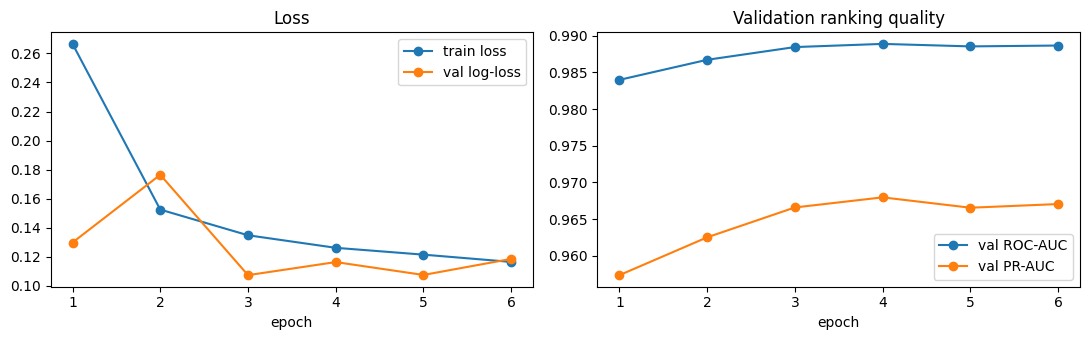

In [18]:
# ▶ CELL 19 — TRAINING CELL (takes a few minutes on a T4 GPU)
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup

set_seed(SEED)
id2label = {0: "Not TB", 1: "TB"}; label2id = {"Not TB": 0, "TB": 1}
try:
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2, id2label=id2label, label2id=label2id)
except Exception as e:
    raise RuntimeError(f"Could not load model '{MODEL_NAME}': {e}")
model.to(DEVICE)

# ---- class weights (computed from TRAINING labels only) ----
counts = np.bincount(y_train, minlength=2)
if USE_CLASS_WEIGHTS:
    class_weights = torch.tensor(len(y_train) / (2.0 * counts), dtype=torch.float, device=DEVICE)
else:
    class_weights = torch.ones(2, device=DEVICE)
print("Training class counts [Not TB, TB]:", counts.tolist(), "| loss weights:", class_weights.cpu().numpy().round(3).tolist())
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

# ---- optimizer: no weight decay on bias / LayerNorm ----
no_decay = ["bias", "LayerNorm.weight"]
params = [
    {"params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)], "weight_decay": WEIGHT_DECAY},
    {"params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)], "weight_decay": 0.0},
]
optimizer = torch.optim.AdamW(params, lr=LEARNING_RATE)
total_steps = len(train_loader) * MAX_EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, int(WARMUP_RATIO * total_steps), total_steps)
try:
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
except (AttributeError, TypeError):                       # older PyTorch
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

@torch.no_grad()
def predict_probs(model, loader):
    """Return P(TB) for every example in the loader (numpy array, values in [0, 1])."""
    model.eval()
    out = []
    for batch in loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items() if k != "labels"}
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            logits = model(**batch).logits
        out.append(torch.softmax(logits.float(), dim=-1)[:, 1].cpu().numpy())
    return np.concatenate(out)

history, best_auc, bad_epochs = [], -1.0, 0
t0 = time.time()
for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    running, n_batches = 0.0, 0
    for batch in train_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        labels = batch.pop("labels")
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            logits = model(**batch).logits
        loss = loss_fn(logits.float(), labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update(); scheduler.step()
        running += loss.item(); n_batches += 1

    vp = predict_probs(model, val_loader)
    val_auc = roc_auc_score(y_val, vp)
    val_pr = average_precision_score(y_val, vp)
    val_ll = log_loss(y_val, np.clip(vp, 1e-6, 1 - 1e-6))
    history.append({"epoch": epoch, "train_loss": running / n_batches, "val_log_loss": val_ll, "val_roc_auc": val_auc, "val_pr_auc": val_pr})
    flag = ""
    if val_auc > best_auc + 1e-4:
        best_auc, bad_epochs = val_auc, 0
        torch.save(model.state_dict(), BEST_CKPT); flag = "  <- best so far, checkpoint saved"
    else:
        bad_epochs += 1
    print(f"Epoch {epoch}/{MAX_EPOCHS} | train loss {running/n_batches:.4f} | val log-loss {val_ll:.4f} | "
          f"val ROC-AUC {val_auc:.4f} | val PR-AUC {val_pr:.4f} | {time.time()-t0:.0f}s{flag}")
    if bad_epochs >= PATIENCE:
        print(f"Early stopping: no improvement for {PATIENCE} epochs."); break

model.load_state_dict(torch.load(BEST_CKPT, map_location=DEVICE))
model.eval()
history_df = pd.DataFrame(history)
print("\nBest checkpoint reloaded. Best validation ROC-AUC:", round(best_auc, 4))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(history_df.epoch, history_df.train_loss, marker="o", label="train loss")
ax[0].plot(history_df.epoch, history_df.val_log_loss, marker="o", label="val log-loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].set_title("Loss")
ax[1].plot(history_df.epoch, history_df.val_roc_auc, marker="o", label="val ROC-AUC")
ax[1].plot(history_df.epoch, history_df.val_pr_auc, marker="o", label="val PR-AUC"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].set_title("Validation ranking quality")
plt.tight_layout(); plt.show()

---
# STEP 11 — Probability prediction: P(TB)

The model's raw output is two numbers (**logits**). A **softmax** turns them into two probabilities that add up to 1. We keep the one for class "TB":

`P(TB) = softmax(logits)[TB]`  →  a number between 0 and 1.

The **predicted class** comes from comparing P(TB) with a **threshold**:
* default threshold = **0.5** → "TB" if P(TB) ≥ 0.5, else "Not TB";
* 0.5 is only a convention. It is not automatically the best choice, especially with class weighting and when you want high sensitivity. Step 12 replaces it with a threshold chosen from validation data.

In [19]:
# ▶ CELL 20 — Get P(TB) for the validation set and show examples
val_probs = predict_probs(model, val_loader)       # numpy array of probabilities, one per validation row
print("All values between 0 and 1:", bool(((val_probs >= 0) & (val_probs <= 1)).all()))
demo = pd.DataFrame({
    "text": df_val["clinical_text"].str.slice(0, 95) + "...",
    "true_label": y_val,
    "P(TB)": val_probs.round(4),
    "predicted @0.5": np.where(val_probs >= 0.5, "TB", "Not TB"),
}).head(8)
display(demo)
m05 = compute_metrics(y_val, val_probs, 0.5)
print("Validation @ default 0.5 ->", {k: round(m05[k], 3) for k in ["accuracy", "precision", "sensitivity", "specificity", "f1", "roc_auc"]})

All values between 0 and 1: True


,text,true_label,P(TB),predicted @0.5
0,51-year-old female. BMI 21.1. HIV negative. No...,0,0.0133,Not TB
1,16-year-old female. BMI 17.1. HIV negative. No...,0,0.0591,Not TB
2,52-year-old female. BMI 24.0. HIV negative. No...,0,0.0011,Not TB
3,40-year-old female. BMI 20.1. HIV positive. No...,1,0.9991,TB
4,35-year-old male. BMI 21.1. HIV positive. Coug...,0,0.9186,TB
5,51-year-old female. BMI 25.1. HIV negative. No...,0,0.0011,Not TB
6,35-year-old male. BMI 22.0. HIV negative. No c...,0,0.0021,Not TB
7,31-year-old male. BMI 17.8. HIV negative. Coug...,1,0.9577,TB


Validation @ default 0.5 -> {'accuracy': 0.957, 'precision': np.float64(0.861), 'sensitivity': np.float64(0.933), 'specificity': np.float64(0.963), 'f1': 0.895, 'roc_auc': np.float64(0.989)}


---
# STEP 12 — Threshold optimisation (validation set ONLY)

Sensitivity (catching TB cases) and specificity (not raising false alarms) trade off against each other as the threshold moves:
* **low threshold** → more people flagged → higher sensitivity, lower specificity/precision;
* **high threshold** → fewer people flagged → lower sensitivity, higher specificity/precision.

**Rule used (set before looking at the test set):** among thresholds whose **validation sensitivity ≥ 0.87** (your 0.85 target + a 0.02 safety margin because sensitivity will vary a little on new data), pick the one with the **highest F1**. If no threshold reaches it, the cell says so and falls back to best F1 — it never pretends the target was met.

After choosing, the threshold is **frozen** (saved to a variable and a file). The test set is evaluated afterwards with that fixed value.

,threshold,sensitivity,specificity,precision,f1,accuracy,tp,fp,fn,tn
0,0.05,0.978,0.839,0.597,0.742,0.866,862,582,19,3037
1,0.10,0.970,0.897,0.696,0.810,0.911,855,374,26,3245
2,0.15,0.964,0.916,0.737,0.835,0.926,849,303,32,3316
3,0.20,0.961,0.928,0.765,0.852,0.935,847,260,34,3359
4,0.25,0.953,0.939,0.791,0.865,0.942,840,222,41,3397
5,0.30,0.949,0.947,0.814,0.876,0.948,836,191,45,3428
6,0.35,0.948,0.953,0.832,0.886,0.952,835,169,46,3450
7,0.40,0.943,0.959,0.849,0.894,0.956,831,148,50,3471
8,0.45,0.936,0.961,0.854,0.893,0.956,825,141,56,3478
9,0.50,0.933,0.963,0.861,0.895,0.957,822,133,59,3486



FROZEN THRESHOLD = 0.85
Rule: best F1 among thresholds with validation sensitivity >= 0.87
Validation at this threshold -> sensitivity 0.893 | specificity 0.984 | precision 0.930 | F1 0.911


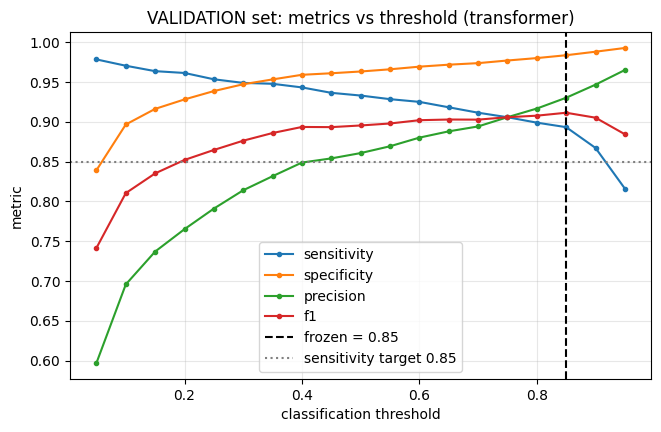

In [20]:
# ▶ CELL 21 — Evaluate thresholds 0.05 ... 0.95 on VALIDATION and freeze the final one
val_tab = threshold_table(y_val, val_probs)
display(val_tab[["threshold", "sensitivity", "specificity", "precision", "f1", "accuracy", "tp", "fp", "fn", "tn"]].round(3))

FROZEN_THRESHOLD, THRESHOLD_RULE = choose_threshold(val_tab)
print(f"\nFROZEN THRESHOLD = {FROZEN_THRESHOLD}")
print("Rule:", THRESHOLD_RULE)
row = val_tab[np.isclose(val_tab.threshold, FROZEN_THRESHOLD)].iloc[0]
print(f"Validation at this threshold -> sensitivity {row.sensitivity:.3f} | specificity {row.specificity:.3f} | "
      f"precision {row.precision:.3f} | F1 {row.f1:.3f}")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for col in ["sensitivity", "specificity", "precision", "f1"]:
    ax.plot(val_tab.threshold, val_tab[col], marker="o", ms=3, label=col)
ax.axvline(FROZEN_THRESHOLD, color="k", ls="--", label=f"frozen = {FROZEN_THRESHOLD}")
ax.axhline(SENSITIVITY_TARGET, color="gray", ls=":", label="sensitivity target 0.85")
ax.set_xlabel("classification threshold"); ax.set_ylabel("metric"); ax.set_title("VALIDATION set: metrics vs threshold (transformer)")
ax.legend(); ax.grid(alpha=.3); plt.show()

# the frozen value is written to disk NOW, before the test set is touched
Path("/content/frozen_threshold.json").write_text(json.dumps({"threshold": FROZEN_THRESHOLD, "rule": THRESHOLD_RULE}))
TEST_SET_USED = False

---
# STEP 13 — Final evaluation on the untouched test set

This is the **first and only time** the test set is used with the transformer. Threshold = the frozen value from Step 12. Do **not** go back, change settings and re-run this cell to "improve" the test score; that would turn the test set into a second validation set.

We report: accuracy, precision, sensitivity, specificity, F1, ROC-AUC, PR-AUC, with **95 % confidence intervals** (bootstrap over patient-id groups), plus the confusion matrix, ROC curve, precision-recall curve and the classification report.

In [21]:
# ▶ CELL 22 — P(TB) for the test set — run this ONCE
assert not globals().get("TEST_SET_USED", False), "Test set already used. Do not re-tune after seeing test results."
test_probs = predict_probs(model, test_loader)
TEST_SET_USED = True
print("Test predictions computed:", test_probs.shape)

Test predictions computed: (4500,)


Transformer, frozen threshold = 0.85


,VALIDATION (used to choose threshold),"TEST (final, untouched)",TEST 95% CI low,TEST 95% CI high
accuracy,0.966,0.966,0.960,0.971
precision,0.930,0.926,0.907,0.943
sensitivity,0.893,0.895,0.873,0.915
specificity,0.984,0.983,0.978,0.987
f1,0.911,0.910,0.895,0.924
roc_auc,0.989,0.993,0.991,0.995
pr_auc,0.968,0.975,0.968,0.981



Classification report (TEST):
              precision    recall  f1-score   support

      Not TB      0.975     0.983     0.979      3621
          TB      0.926     0.895     0.910       879

    accuracy                          0.966      4500
   macro avg      0.950     0.939     0.945      4500
weighted avg      0.965     0.966     0.965      4500



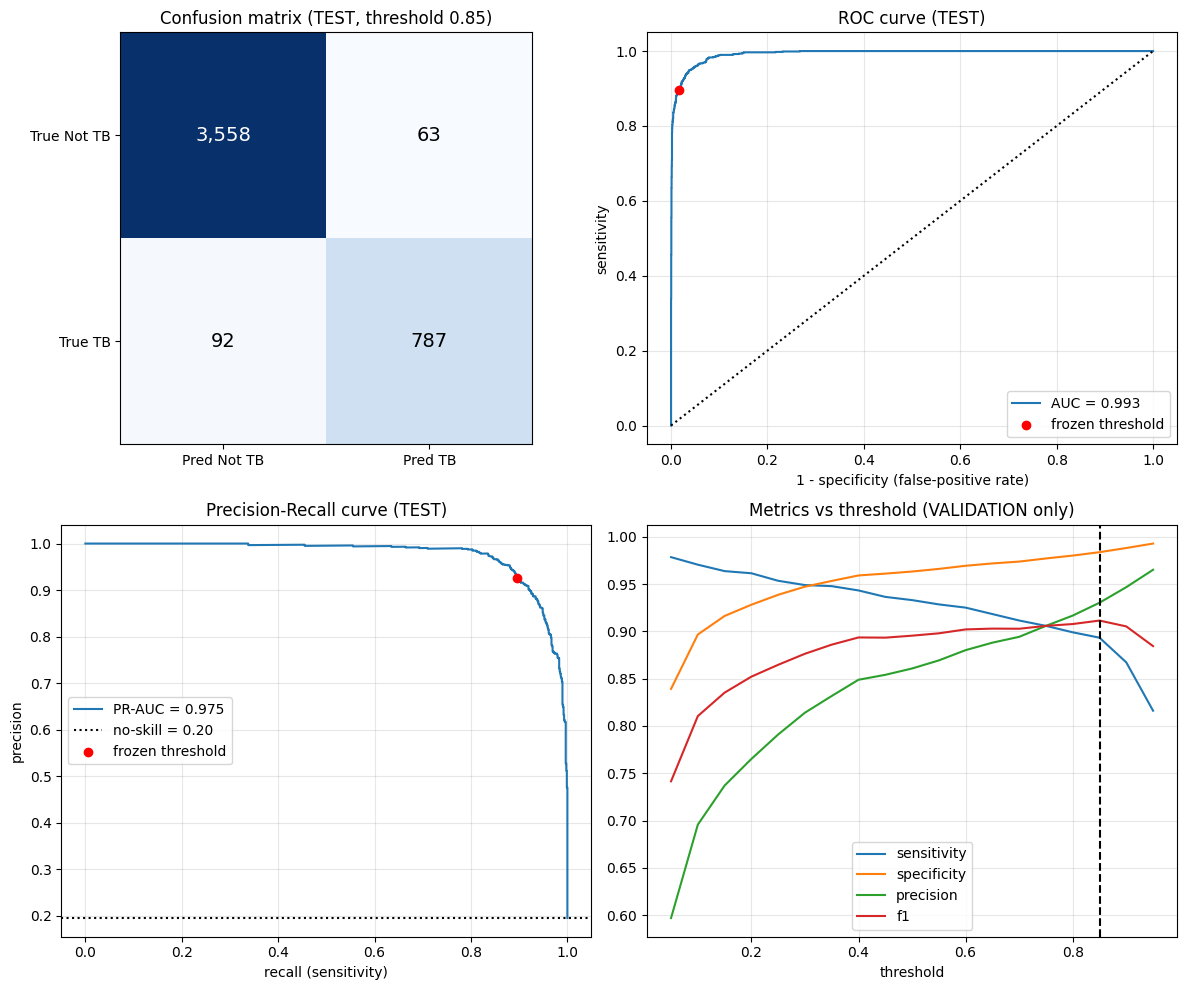

Test results by setting (same frozen threshold). Precision depends on how common TB is in each setting:


,setting,n,tb_rate,precision,sensitivity,specificity,f1,roc_auc
0,high,1500,0.351,0.958,0.903,0.978,0.930,0.993
1,moderate,1500,0.171,0.931,0.887,0.986,0.908,0.991
2,low,1500,0.064,0.771,0.875,0.982,0.820,0.993


In [22]:
# ▶ CELL 23 — Final test evaluation with the FROZEN threshold
test_metrics = compute_metrics(y_test, test_probs, FROZEN_THRESHOLD)
val_metrics  = compute_metrics(y_val, val_probs, FROZEN_THRESHOLD)
groups_test = df_test[ID_COL].values if GROUPS_AVAILABLE else None
ci = bootstrap_ci(y_test, test_probs, FROZEN_THRESHOLD, groups=groups_test)

keys = ["accuracy", "precision", "sensitivity", "specificity", "f1", "roc_auc", "pr_auc"]
cmp_vt = pd.DataFrame({"VALIDATION (used to choose threshold)": {k: val_metrics[k] for k in keys},
                       "TEST (final, untouched)": {k: test_metrics[k] for k in keys},
                       "TEST 95% CI low": {k: ci[k][0] for k in keys},
                       "TEST 95% CI high": {k: ci[k][1] for k in keys}})
print(f"Transformer, frozen threshold = {FROZEN_THRESHOLD}")
display(cmp_vt.round(3))

y_pred_test = (test_probs >= FROZEN_THRESHOLD).astype(int)
print("\nClassification report (TEST):")
print(classification_report(y_test, y_pred_test, target_names=["Not TB", "TB"], digits=3))

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
# 1 confusion matrix
cm = confusion_matrix(y_test, y_pred_test, labels=[0, 1])
ax[0, 0].imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax[0, 0].text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=14, color="white" if cm[i, j] > cm.max() / 2 else "black")
ax[0, 0].set_xticks([0, 1]); ax[0, 0].set_xticklabels(["Pred Not TB", "Pred TB"]); ax[0, 0].set_yticks([0, 1]); ax[0, 0].set_yticklabels(["True Not TB", "True TB"])
ax[0, 0].set_title(f"Confusion matrix (TEST, threshold {FROZEN_THRESHOLD})")
# 2 ROC
fpr, tpr, _ = roc_curve(y_test, test_probs)
ax[0, 1].plot(fpr, tpr, label=f"AUC = {test_metrics['roc_auc']:.3f}"); ax[0, 1].plot([0, 1], [0, 1], "k:")
ax[0, 1].scatter([1 - test_metrics["specificity"]], [test_metrics["sensitivity"]], c="r", zorder=5, label="frozen threshold")
ax[0, 1].set_xlabel("1 - specificity (false-positive rate)"); ax[0, 1].set_ylabel("sensitivity"); ax[0, 1].set_title("ROC curve (TEST)"); ax[0, 1].legend(); ax[0, 1].grid(alpha=.3)
# 3 PR
pr, rc, _ = precision_recall_curve(y_test, test_probs)
ax[1, 0].plot(rc, pr, label=f"PR-AUC = {test_metrics['pr_auc']:.3f}"); ax[1, 0].axhline(y_test.mean(), color="k", ls=":", label=f"no-skill = {y_test.mean():.2f}")
ax[1, 0].scatter([test_metrics["sensitivity"]], [test_metrics["precision"]], c="r", zorder=5, label="frozen threshold")
ax[1, 0].set_xlabel("recall (sensitivity)"); ax[1, 0].set_ylabel("precision"); ax[1, 0].set_title("Precision-Recall curve (TEST)"); ax[1, 0].legend(); ax[1, 0].grid(alpha=.3)
# 4 threshold curve (validation)
for col in ["sensitivity", "specificity", "precision", "f1"]:
    ax[1, 1].plot(val_tab.threshold, val_tab[col], label=col)
ax[1, 1].axvline(FROZEN_THRESHOLD, color="k", ls="--"); ax[1, 1].set_title("Metrics vs threshold (VALIDATION only)"); ax[1, 1].set_xlabel("threshold"); ax[1, 1].legend(); ax[1, 1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print("Test results by setting (same frozen threshold). Precision depends on how common TB is in each setting:")
rows = []
for b_name in ["high", "moderate", "low"]:
    mask = (df_test["burden"] == b_name).values
    if mask.sum() and len(np.unique(y_test[mask])) == 2:
        mm = compute_metrics(y_test[mask], test_probs[mask], FROZEN_THRESHOLD)
        rows.append({"setting": b_name, "n": int(mask.sum()), "tb_rate": y_test[mask].mean(), **{k: mm[k] for k in ["precision", "sensitivity", "specificity", "f1", "roc_auc"]}})
display(pd.DataFrame(rows).round(3))

---
# STEP 14 — Baseline vs transformer (all on the same untouched test set)

Every model uses **its own threshold that was chosen on validation data** (same rule for all). Now that all choices are frozen, the baselines are evaluated on the test set too, so the comparison is fair.

In [23]:
# ▶ CELL 24 — Final comparison table (computed from real predictions; nothing is typed in by hand)
TRANSFORMER_NAME = "Transformer (" + MODEL_NAME.split("/")[-1] + ")"
all_models = {}
for name, r in results.items():
    r["test_probs"] = r["model"].predict_proba(baseline_inputs(name, df_test))[:, 1]
    all_models[name] = (r["val_probs"], r["test_probs"], r["thr"])
all_models[TRANSFORMER_NAME] = (val_probs, test_probs, FROZEN_THRESHOLD)

cols = ["threshold", "accuracy", "precision", "sensitivity", "specificity", "f1", "roc_auc", "pr_auc"]
comparison_test = pd.DataFrame({n: compute_metrics(y_test, tp_, thr) for n, (vp_, tp_, thr) in all_models.items()}).T[cols]
comparison_val  = pd.DataFrame({n: compute_metrics(y_val,  vp_, thr) for n, (vp_, tp_, thr) in all_models.items()}).T[cols]
comparison_test.columns = ["Threshold", "Accuracy", "Precision", "Sensitivity", "Specificity", "F1", "ROC-AUC", "PR-AUC"]
comparison_val.columns = comparison_test.columns

print("TEST SET (final):")
display(comparison_test.round(3))
print("VALIDATION SET (for reference; thresholds were chosen here, so these numbers are optimistic):")
display(comparison_val.round(3))

print("\nResearch targets on the TEST set  (F1 > 0.80, ROC-AUC > 0.85, Sensitivity > 0.85):")
for n in comparison_test.index:
    r_ = comparison_test.loc[n]
    ok = lambda v, t: "MET" if v > t else "NOT MET"
    print(f"  {n:46s} F1 {r_['F1']:.3f} [{ok(r_['F1'], .80)}] | AUC {r_['ROC-AUC']:.3f} [{ok(r_['ROC-AUC'], .85)}] | Sens {r_['Sensitivity']:.3f} [{ok(r_['Sensitivity'], .85)}]")

best_tab = comparison_test.drop(index=[TRANSFORMER_NAME])["ROC-AUC"].max()
print("\nHow to read this honestly:")
print(f"  - Best table/baseline test ROC-AUC: {best_tab:.3f}  vs transformer: {comparison_test.loc[TRANSFORMER_NAME, 'ROC-AUC']:.3f}")
print("  - If the numbers are close, the transformer is adding no real information (it reads the same symptoms as the tables).")
print("  - Very high scores on this data should NOT be presented as expected real-world performance (see Step 20).")

TEST SET (final):


,Threshold,Accuracy,Precision,Sensitivity,Specificity,F1,ROC-AUC,PR-AUC
TF-IDF + Logistic Regression,0.70,0.966,0.915,0.910,0.980,0.913,0.993,0.975
Structured Logistic Regression,0.55,0.963,0.875,0.947,0.967,0.909,0.993,0.977
Structured Gradient Boosting,0.65,0.966,0.903,0.927,0.976,0.915,0.992,0.974
Transformer (Bio_ClinicalBERT),0.85,0.966,0.926,0.895,0.983,0.910,0.993,0.975


VALIDATION SET (for reference; thresholds were chosen here, so these numbers are optimistic):


,Threshold,Accuracy,Precision,Sensitivity,Specificity,F1,ROC-AUC,PR-AUC
TF-IDF + Logistic Regression,0.70,0.962,0.902,0.907,0.976,0.904,0.988,0.965
Structured Logistic Regression,0.55,0.963,0.880,0.940,0.969,0.909,0.989,0.968
Structured Gradient Boosting,0.65,0.963,0.895,0.918,0.974,0.906,0.988,0.966
Transformer (Bio_ClinicalBERT),0.85,0.966,0.930,0.893,0.984,0.911,0.989,0.968



Research targets on the TEST set  (F1 > 0.80, ROC-AUC > 0.85, Sensitivity > 0.85):
  TF-IDF + Logistic Regression                   F1 0.913 [MET] | AUC 0.993 [MET] | Sens 0.910 [MET]
  Structured Logistic Regression                 F1 0.909 [MET] | AUC 0.993 [MET] | Sens 0.947 [MET]
  Structured Gradient Boosting                   F1 0.915 [MET] | AUC 0.992 [MET] | Sens 0.927 [MET]
  Transformer (Bio_ClinicalBERT)                 F1 0.910 [MET] | AUC 0.993 [MET] | Sens 0.895 [MET]

How to read this honestly:
  - Best table/baseline test ROC-AUC: 0.993  vs transformer: 0.993
  - If the numbers are close, the transformer is adding no real information (it reads the same symptoms as the tables).
  - Very high scores on this data should NOT be presented as expected real-world performance (see Step 20).


---
# STEP 15 — Save the trained model, tokenizer and settings to Google Drive

We save into **`/content/drive/MyDrive/TB_NLP_Model/`**:

| File / folder | Content |
|---|---|
| `model/` | fine-tuned transformer weights |
| `tokenizer/` | tokenizer files |
| `label_mapping.json` | 0 ↔ "Not TB", 1 ↔ "TB" |
| `preprocessing_config.json` | text template version, features used, removed columns, max length, seed, library versions |
| `threshold.json` | the frozen classification threshold and the rule used |
| `metrics.json` | validation + test metrics, confidence intervals, comparison table |
| `splits.json` | which patient ids were train/val/test (for reproducibility) |
| `tb_utils.py` | the exact text-building function used in training |
| `baselines.joblib` | the three baseline models |

In [24]:
# ▶ CELL 25 — Mount Google Drive and save the model + tokenizer
from google.colab import drive
drive.mount("/content/drive")

SAVE_DIR.mkdir(parents=True, exist_ok=True)
model.save_pretrained(SAVE_DIR / "model")
tokenizer.save_pretrained(SAVE_DIR / "tokenizer")
shutil.copy("/content/tb_utils.py", SAVE_DIR / "tb_utils.py")
print("Saved model, tokenizer and tb_utils.py to", SAVE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model, tokenizer and tb_utils.py to /content/drive/MyDrive/TB_NLP_Model


In [25]:
# ▶ CELL 26 — Save label mapping, preprocessing config, threshold, metrics, splits (plain JSON files)
import joblib
SAVE_DIR.mkdir(parents=True, exist_ok=True)

def to_py(o):
    """Make numpy / pandas values JSON-friendly."""
    if isinstance(o, dict):                    return {str(k): to_py(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):           return [to_py(v) for v in o]
    if isinstance(o, (np.integer,)):           return int(o)
    if isinstance(o, (np.floating, float)):    return None if (isinstance(o, float) and math.isnan(o)) else float(o)
    if isinstance(o, np.ndarray):              return to_py(o.tolist())
    if isinstance(o, pd.DataFrame):            return to_py(o.to_dict(orient="index"))
    return o

def versions():
    v = {"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__, "torch": getattr(torch, "__version__", "n/a")}
    for lib in ("transformers", "sklearn"):
        try: v[lib] = importlib.import_module(lib).__version__
        except Exception: v[lib] = "n/a"
    v["gpu"] = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"
    return v

label_mapping = {"id2label": {"0": "Not TB", "1": "TB"}, "label2id": {"Not TB": 0, "TB": 1}, "positive_class": "TB",
                 "target_column": TARGET_COL, "note": "Label comes from the patient-level column; never from the 'burden' file name."}

preprocessing_config = {
    "template_version": getattr(tb_utils, "TEMPLATE_VERSION", "v1"),
    "text_builder": "tb_utils.build_clinical_text",
    "lowercase": False, "stopwords_removed": False,
    "model_name": MODEL_NAME, "max_len": int(MAX_LEN),
    "id_col": ID_COL, "free_text_col": FREE_TEXT_COL,
    "model_input_features": MODEL_FEATURE_COLS,
    "removed_leakage_columns": LEAKAGE_COLS, "removed_derived_columns": DERIVED_COLS,
    "burden_used_as_feature": False,
    "split": "70/15/15, stratified, grouped by patient id" if GROUPS_AVAILABLE else "70/15/15 stratified at row level (no id)",
    "seed": SEED, "class_weights_used": bool(USE_CLASS_WEIGHTS),
    "hyperparameters": {"learning_rate": LEARNING_RATE, "batch_size": BATCH_SIZE, "max_epochs": MAX_EPOCHS, "patience": PATIENCE,
                        "weight_decay": WEIGHT_DECAY, "warmup_ratio": WARMUP_RATIO},
    "versions": versions(),
}
threshold_info = {"threshold": float(FROZEN_THRESHOLD), "rule": THRESHOLD_RULE, "chosen_on": "validation set only",
                  "sensitivity_target": SENSITIVITY_TARGET, "safety_margin": SAFETY_MARGIN}
metrics_out = {
    "validation_at_frozen_threshold": val_metrics,
    "test_at_frozen_threshold": test_metrics,
    "test_95ci_bootstrap_by_patient_group": ci,
    "comparison_test": comparison_test.round(4).to_dict(orient="index"),
    "comparison_validation": comparison_val.round(4).to_dict(orient="index"),
    "validation_threshold_table": val_tab.round(4).to_dict(orient="records"),
    "warning": "Research prototype. Not clinically validated. See Step 20 of the notebook.",
}
splits = {s: sorted(int(i) for i in df_all.loc[df_all.split == s, ID_COL].unique()) for s in ("train", "val", "test")} if GROUPS_AVAILABLE else {}

for fname, obj in [("label_mapping.json", label_mapping), ("preprocessing_config.json", preprocessing_config),
                   ("threshold.json", threshold_info), ("metrics.json", metrics_out), ("splits.json", splits)]:
    (SAVE_DIR / fname).write_text(json.dumps(to_py(obj), indent=2))
joblib.dump({n: r["model"] for n, r in results.items()}, SAVE_DIR / "baselines.joblib")
if Path("/content/tb_utils.py").exists():
    shutil.copy("/content/tb_utils.py", SAVE_DIR / "tb_utils.py")
print("Saved to", SAVE_DIR)
for p in sorted(SAVE_DIR.iterdir()):
    print("  ", p.name)

Saved to /content/drive/MyDrive/TB_NLP_Model
   baselines.joblib
   label_mapping.json
   metrics.json
   model
   preprocessing_config.json
   splits.json
   tb_utils.py
   threshold.json
   tokenizer


---
# STEP 16 — Reload the saved model (works after a Colab restart)

To prove it works: **Runtime → Restart session**. Then run **only** the reload cell below and then the two Step 17 cells (the functions + the try-it cell). Nothing from earlier steps is needed except the files in Google Drive. (If Colab says `transformers` is missing, run the install cell, CELL 2, once.)

In [26]:
# ▶ CELL 27 — Reload everything from Google Drive (can be run in a brand-new session)
import os, sys, json, torch
import numpy as np
from pathlib import Path
from google.colab import drive
drive.mount("/content/drive")

MODEL_DIR = Path("/content/drive/MyDrive/TB_NLP_Model")
if not MODEL_DIR.exists():
    raise FileNotFoundError(f"{MODEL_DIR} not found. Run Step 15 first.")

sys.path.insert(0, str(MODEL_DIR))
import importlib, tb_utils
importlib.reload(tb_utils)
from tb_utils import build_clinical_text, clean_text

from transformers import AutoTokenizer, AutoModelForSequenceClassification
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR / "tokenizer")
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR / "model").to(DEVICE).eval()
cfg = json.loads((MODEL_DIR / "preprocessing_config.json").read_text())
label_mapping = json.loads((MODEL_DIR / "label_mapping.json").read_text())
THRESHOLD = float(json.loads((MODEL_DIR / "threshold.json").read_text())["threshold"])
MAX_LEN = int(cfg["max_len"])
RELOAD_TESTED = True
print("Reloaded. Device:", DEVICE, "| MAX_LEN:", MAX_LEN, "| threshold:", THRESHOLD, "| labels:", label_mapping["id2label"])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Reloaded. Device: cuda | MAX_LEN: 64 | threshold: 0.85 | labels: {'0': 'Not TB', '1': 'TB'}


---
# STEP 17 — Predict TB probability for new text or structured symptoms



In [27]:
# ▶ CELL 28 — Prediction functions (work right after training AND after reloading)
THRESHOLD = globals().get("THRESHOLD", globals().get("FROZEN_THRESHOLD"))
assert THRESHOLD is not None, "Run Step 12 (or Step 16) first."
model.eval()

@torch.no_grad()
def _prob_from_text(text: str) -> float:
    enc = tokenizer(text, truncation=True, max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
    logits = model(**enc).logits
    return float(torch.softmax(logits.float(), dim=-1)[0, 1].item())      # P(TB)

TRAINING_FIELDS = ["age_years", "sex", "bmi", "hiv_status", "cough_2weeks", "cough_duration_weeks", "fever", "night_sweats",
                   "weight_loss", "hemoptysis", "chest_pain", "fatigue", "loss_of_appetite"]

def _format_result(p, thr, text, verbose, warning=None):
    out = {"tb_probability": round(p, 4), "prediction": "TB" if p >= thr else "Not TB", "threshold": thr, "input_text": text}
    if warning: out["warning"] = warning
    if verbose:
        print(f"TB Probability: {p:.2f}\nPrediction: {out['prediction']}\nThreshold: {thr:.2f}")
        if warning: print("Warning:", warning)
    return out

def predict_tb(text: str, threshold: float = None, verbose: bool = True) -> dict:
    """Free-text input. Less reliable than predict_tb_structured (text format differs from training)."""
    thr = THRESHOLD if threshold is None else threshold
    text = clean_text(text)
    if not text:
        raise ValueError("Empty text.")
    warn = ("Free-text input is outside the training format (the model was trained on templated sentences with all fields). "
            "Treat this probability as unreliable; prefer predict_tb_structured().")
    return _format_result(_prob_from_text(text), thr, text, verbose, warn)

def predict_tb_structured(threshold: float = None, verbose: bool = True, **fields) -> dict:
    """Structured input, e.g. predict_tb_structured(age_years=34, sex='F', bmi=17.5, hiv_status=1, cough_duration_weeks=4, fever=1, ...)
    Missing fields are written as 'not recorded' in the text (never silently treated as 'no')."""
    unknown = [k for k in fields if k not in TRAINING_FIELDS]
    if unknown:
        print("Ignored unknown fields:", unknown, "| valid fields:", TRAINING_FIELDS)
    rec = {k: v for k, v in fields.items() if k in TRAINING_FIELDS}
    if rec.get("cough_duration_weeks") is not None and "cough_2weeks" not in rec:
        rec["cough_2weeks"] = int(float(rec["cough_duration_weeks"]) >= 2)
    thr = THRESHOLD if threshold is None else threshold
    text = build_clinical_text(rec)
    return _format_result(_prob_from_text(text), thr, text, verbose)

def predict_tb_batch(df, batch_size=64):
    """Return a numpy array of P(TB) for a dataframe that has the training columns."""
    texts = [build_clinical_text(r) for _, r in df.iterrows()]
    probs = []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(texts[i:i + batch_size], padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            probs.append(torch.softmax(model(**enc).logits.float(), dim=-1)[:, 1].cpu().numpy())
    return np.concatenate(probs)

print("Functions ready: predict_tb, predict_tb_structured, predict_tb_batch")

Functions ready: predict_tb, predict_tb_structured, predict_tb_batch


In [28]:
# ▶ CELL 29 — Try it. The numbers printed below come from YOUR trained model.
print("--- 1) Free text (less reliable, see warning) ---")
r1 = predict_tb("Patient has persistent cough for 4 weeks, fever, night sweats and significant weight loss.")

print("\n--- 2) Structured symptoms (recommended) ---")
r2 = predict_tb_structured(age_years=34, sex="F", bmi=17.5, hiv_status=1, cough_duration_weeks=4,
                           fever=1, night_sweats=1, weight_loss=1, hemoptysis=0, chest_pain=0, fatigue=1, loss_of_appetite=1)

print("\n--- 3) Structured, low-symptom patient ---")
r3 = predict_tb_structured(age_years=29, sex="M", bmi=24.0, hiv_status=0, cough_duration_weeks=0,
                           fever=0, night_sweats=0, weight_loss=0, hemoptysis=0, chest_pain=0, fatigue=0, loss_of_appetite=0)
print("\nText the model actually saw in example 2:\n ", r2["input_text"])

--- 1) Free text (less reliable, see warning) ---
TB Probability: 0.96
Prediction: TB
Threshold: 0.85

--- 2) Structured symptoms (recommended) ---
TB Probability: 1.00
Prediction: TB
Threshold: 0.85

--- 3) Structured, low-symptom patient ---
TB Probability: 0.00
Prediction: Not TB
Threshold: 0.85

Text the model actually saw in example 2:
  34-year-old female. BMI 17.5. HIV positive. Cough for 4 weeks. Reports fever. Reports night sweats. Reports weight loss. Denies hemoptysis (coughing up blood). Denies chest pain. Reports fatigue. Reports loss of appetite.


In [29]:
# ▶ CELL 30 — Clean numeric output for the future fusion model
def get_tb_nlp_probability(x) -> dict:
    """x = dict of structured symptoms (recommended) OR a text string. Returns {'tb_probability': float in [0,1]}."""
    if isinstance(x, dict):
        rec = dict(x)
        if rec.get("cough_duration_weeks") is not None and "cough_2weeks" not in rec:
            rec["cough_2weeks"] = int(float(rec["cough_duration_weeks"]) >= 2)
        text = build_clinical_text(rec)
    else:
        text = clean_text(x)
    return {"tb_probability": round(_prob_from_text(text), 6)}

example = get_tb_nlp_probability({"age_years": 34, "sex": "F", "bmi": 17.5, "hiv_status": 1, "cough_duration_weeks": 4,
                                  "fever": 1, "night_sweats": 1, "weight_loss": 1, "hemoptysis": 0, "chest_pain": 0,
                                  "fatigue": 1, "loss_of_appetite": 1})
print(example)

{'tb_probability': 0.999711}


---
# STEP 19 — Reproducibility

**What this notebook already does**
* `set_seed(42)` fixes Python, NumPy and PyTorch (CPU + GPU) random generators, and forces deterministic cuDNN (CELL 3).
* The data split uses the same seed, and the exact patient ids of each split are saved in `splits.json`.
* The DataLoader shuffle uses a seeded generator.
* Library versions, GPU name, hyper-parameters and the text-template version are saved in `preprocessing_config.json`.

**What cannot be guaranteed on Colab**
* Mixed-precision (fp16) GPU maths and some CUDA kernels are not bit-for-bit deterministic. Two runs can differ in the 3rd decimal.
* Colab can give a different GPU type or library version on different days.

**Good practice:** for a paper, repeat the training with 3–5 different seeds (change `SEED`, re-run from CELL 3) and report mean ± standard deviation, not a single lucky run.

---
# FINAL — Project checklist (computed from what you actually ran)

Run the cell below at the end. It marks each requirement as done/not done based on variables and files that really exist, and compares your real test metrics with your targets.

In [30]:
# ▶ CELL 31 — Final checklist (nothing here is typed in by hand; it inspects your session)
G = globals()
exists = lambda p: Path(p).exists()
saved_files = ["label_mapping.json", "preprocessing_config.json", "threshold.json", "metrics.json", "tb_utils.py"]
items = [
    ("Step 1  Colab GPU setup (training used GPU)",                       DEVICE.type == "cuda"),
    ("Step 2  CSVs uploaded & verified",                                  len(G.get("found", {})) == 3),
    ("Step 3  Datasets inspected before modelling",                       "raw" in G and "roles" in G),
    ("Step 4  Files checked and combined; label = patient-level column",  "df_all" in G and TARGET_COL in df_all.columns),
    ("Step 5  Leakage columns removed + split by patient id (70/15/15)",  "df_test" in G and bool(LEAKAGE_COLS) and G.get("GROUPS_AVAILABLE", False)),
    ("Step 6  NLP preprocessing (text + structured)",                     "clinical_text" in G.get("df_all", pd.DataFrame()).columns),
    ("Step 7  Baselines (TF-IDF+LR, structured LR/GB)",                   "results" in G),
    ("Step 8  Model chosen (Bio_ClinicalBERT) with justification",        "MODEL_NAME" in G),
    ("Step 9  Tokenization with measured max length",                     "MAX_LEN" in G),
    ("Step 10 Fine-tuned (class weights, early stopping, best checkpoint)", "history_df" in G),
    ("Step 11 P(TB) probabilities produced",                              "val_probs" in G),
    ("Step 12 Threshold chosen on validation only and frozen",            "FROZEN_THRESHOLD" in G),
    ("Step 13 Final test evaluation (once, frozen threshold)",            G.get("TEST_SET_USED", False) and "test_metrics" in G),
    ("Step 14 Baseline vs transformer comparison table",                  "comparison_test" in G),
    ("Step 15 Everything saved to Google Drive",                          "SAVE_DIR" in G and all(exists(SAVE_DIR / f) for f in saved_files)),
    ("Step 16 Reload tested after restart",                               G.get("RELOAD_TESTED", False)),
    ("Step 17 predict_tb / predict_tb_structured available",              "predict_tb" in G),
    ("Step 18 Fusion-ready {'tb_probability': ...} output",               "get_tb_nlp_probability" in G),
    ("Step 19 Seeds set (Python/NumPy/PyTorch)",                          "set_seed" in G),
    ("Step 20 Research considerations (read the Step 20 text)",           True),
]
for label, ok in items:
    print(("DONE      " if ok else "NOT DONE  ") + label)

if "test_metrics" in G:
    print("\nYour research targets vs REAL test results of the transformer (threshold %.2f):" % FROZEN_THRESHOLD)
    for nm, key, tgt in [("F1-score", "f1", 0.80), ("ROC-AUC", "roc_auc", 0.85), ("Sensitivity", "sensitivity", 0.85)]:
        v = test_metrics[key]; lo, hi = ci[key]
        print(f"  {nm:12s} target > {tgt:.2f} | test = {v:.3f} (95% CI {lo:.3f}-{hi:.3f}) -> {'MET' if v > tgt else 'NOT MET'}")
    print("\nReminder: meeting targets on this dataset is NOT evidence of clinical performance (see Step 20).")

DONE      Step 1  Colab GPU setup (training used GPU)
DONE      Step 2  CSVs uploaded & verified
DONE      Step 3  Datasets inspected before modelling
DONE      Step 4  Files checked and combined; label = patient-level column
DONE      Step 5  Leakage columns removed + split by patient id (70/15/15)
DONE      Step 6  NLP preprocessing (text + structured)
DONE      Step 7  Baselines (TF-IDF+LR, structured LR/GB)
DONE      Step 8  Model chosen (Bio_ClinicalBERT) with justification
DONE      Step 9  Tokenization with measured max length
DONE      Step 10 Fine-tuned (class weights, early stopping, best checkpoint)
DONE      Step 11 P(TB) probabilities produced
DONE      Step 12 Threshold chosen on validation only and frozen
DONE      Step 13 Final test evaluation (once, frozen threshold)
DONE      Step 14 Baseline vs transformer comparison table
DONE      Step 15 Everything saved to Google Drive
DONE      Step 16 Reload tested after restart
DONE      Step 17 predict_tb / predict_tb_structu

**Prediction**

In [39]:
result = predict_tb_structured(
    age_years=34,
    sex="F",                   # "M" or "F"
    bmi=18.5,
    hiv_status=1,              # 1 = HIV positive, 0 = negative
    cough_duration_weeks=4,    # 0 = no cough
    fever=1,                   # 1 = yes, 0 = no
    night_sweats=1,
    weight_loss=1,
    hemoptysis=0,              # coughing up blood
    chest_pain=1,
    fatigue=0,
    loss_of_appetite=1,
)

TB Probability: 1.00
Prediction: TB
Threshold: 0.85
